In [25]:
import pandas as pd
import numpy as np
from plotnine import *
from anndata import read_h5ad


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [22]:
# adata = read_h5ad('/Users/kylekimler/Projects/GCA/meta_datasets/gca_concatenated_anndata_Jan28_2025.h5ad')
# # adata
# meta = adata.obs


In [26]:
# meta = pd.read_csv('/Users/kylekimler/Projects/GCA/meta_datasets/plotting_metadata.csv')
# meta = pd.read_csv('/Users/kylekimler/Projects/GCA/meta_datasets/sample_only_plotting_obs.csv')
meta = pd.read_csv('/Users/kylekimler/Projects/GCA/meta_datasets/gca_concatenated_metadata_March28_2025.csv')


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/1640379357.py:3: DtypeWarning: Columns (1,2,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,23,24,25,26,27,28,29,30,31,32,33,34,35,36,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58) have mixed types. Specify dtype option on import or set low_memory=False.


In [27]:
print(len(meta['dataset_id'].unique()))

32


In [28]:
print(*meta['dataset_id'].unique())

Dominguez2022 James2020 snRNAseq multiome Egozi2023 BasuGCARNA Zheng2024 He2020 Huang2019 Kinchen2018 Yu2021 ArendsHelmsley Burclaff2022 nan DominguezUnpub KarakashevaHelmlsey Krzak2023 Maddipatla2023 Smillie2019 Kong2023 Elmentaite2020 Jaeger2021 Lee2020 Martin2019 Parikh2019 Uzzan2022 Wang2020 Luoma2020 AgaceHelmsley3 AgaceHelmsley2 AgaceHelmsley1 Drokhylansky2020


In [29]:
print(len(meta['donor_id'].unique()))

407


In [30]:
print(len(meta['sample_id'].unique()))

863


In [31]:
meta.shape

(3381939, 59)

In [32]:
meta['cell_id'] = meta.index

In [33]:
summary_df = meta.groupby('dataset_id').agg(
    total_samples=('sample_id', 'nunique'),
    total_donors=('donor_id', 'nunique'),
    total_cells=('cell_id', 'size')  # Assuming 'cell_id' is the index or a column in the .obs attribute
).reset_index()


In [34]:
totals_df = summary_df
totals_df['dataset_id'] = 1

In [35]:
summary_df

,dataset_id,total_samples,total_donors,total_cells
0,1,2,1,9084
1,1,8,5,125930
2,1,34,5,599381
3,1,4,4,25661
4,1,27,14,127257
5,1,18,3,12590
6,1,9,5,1790
7,1,9,5,39111
8,1,61,15,148467
9,1,15,13,135492


In [36]:
# df_dataset = pd.read_csv('/Users/kylekimler/git2/hca-gut-atlas-extension/src/harmonized_metadata/concatenated_dataset_metadata.csv').drop(columns=['index'])
# df_sample = pd.read_csv('/Users/kylekimler/git2/hca-gut-atlas-extension/src/harmonized_metadata/concatenated_sample_metadata.csv').drop(columns=['index'])
# df_donor = pd.read_csv('/Users/kylekimler/git2/hca-gut-atlas-extension/src/harmonized_metadata/concatenated_donor_metadata.csv').drop(columns=['index'])

# # df_dataset.shape
# df_sample.shape
# # df_donor.shape

In [37]:
# df_sample['age_range']

In [38]:
# # Assuming df_donor is your DataFrame
# # Convert the entire column to string first, handling NaN appropriately
# df_sample['age_range'] = df_sample['age_range'].astype(str)

# def fix_age_range(age_range):
#     if '-' in age_range:  # Check if the hyphen is in the string
#         ages = age_range.split('-')
#         if len(ages) == 2:
#             # Adjust the upper age by subtracting 1
#             upper_age = int(ages[1]) - 1
#             # Return the corrected age range
#             return f"{ages[0]}-{upper_age}"
#     return age_range  # Return original if not in the expected format

# # Apply the function to the 'age_range' column
# df_sample['age_range'] = df_sample['age_range'].apply(fix_age_range)

In [39]:
# df_dataset['dataset_id'] = df_dataset['title']

In [40]:
df_sample.columns

NameError: name 'df_sample' is not defined

In [ ]:
# def create_faceted_bar_graph_v2(df_dataset, df_sample, df_donor, color_palette):
#     # Calculate donor counts from df_donor
#     donor_counts = df_donor.groupby('dataset_id')['donor_id'].nunique().reset_index()
#     donor_counts = donor_counts.rename(columns={'donor_id': 'Count'})
#     donor_counts['Category'] = 'Donors'

#     # Calculate sample counts from df_sample
#     sample_counts = df_sample.groupby('dataset_id')['sample_id'].nunique().reset_index()
#     sample_counts = sample_counts.rename(columns={'sample_id': 'Count'})
#     sample_counts['Category'] = 'Samples'

#     # Concatenate donor and sample counts into one DataFrame
#     combined_counts = pd.concat([donor_counts, sample_counts], ignore_index=True)

#     # Merge with df_dataset to get additional dataset information, if needed
#     # Assuming 'dataset_id' is the key column to join on
#     merged_df = pd.merge(combined_counts, df_dataset[['dataset_id']], on='dataset_id', how='left')

#     # Create the plot
#     p = (
#         ggplot(merged_df, aes(x='dataset_id', y='Count', fill='Category'))
#         + geom_bar(stat='identity', position='dodge')
#         + coord_flip()
#         + facet_wrap('~Category', scales='free')
#         + theme_classic(base_size=14)
#         + theme(
#             axis_text_x=element_text(rotation=45, hjust=0.5), 
#             axis_text_y=element_text(hjust=1),
#             legend_position='right', 
#             subplots_adjust={'right': 0.85},
#             figure_size=(16, 8)
#         )
#         + scale_fill_manual(values=color_palette)
#         + labs(title='Atlas Summary by Dataset ID', x='Dataset ID', y='Count')
#     )

#     # Remove y-axis tick labels for the second facet
#     p = p + theme(
#         strip_text_y=element_text(color='black', size=10)
#     )

#     return p

# color_palette = ['#1f77b4', '#ff7f0e']
# plot = create_faceted_bar_graph_v2(df_dataset, df_sample, df_donor, color_palette)


In [ ]:
# title_count = melted_df[melted_df['Category'] == 'title'].shape[0]  # Count all entries with 'title'
# other_metrics = melted_df[melted_df['Category'] != 'title'].groupby('Category').sum().reset_index()

# # Creating a new summary dataframe
# summary_df = pd.DataFrame({
#     'Category': ['title'] + other_metrics['Category'].tolist(),
#     'Count': [title_count] + other_metrics['Count'].tolist()
# })


In [ ]:
# p = (ggplot(summary_df, aes(x='Category', y='Count', fill='Category'))
#      + geom_bar(stat='identity', position='dodge')
#      + geom_text(aes(label='Count'),
#                  position=position_dodge(width=0.9),  # Adjust this width as necessary
#                  va='bottom', size=8)
#      + coord_flip()
#      + theme_minimal()
#      + labs(title='Summary of Data', y='Total Count', x='Metric')
# )
# p.show()  # Use show method to display the plot

In [ ]:
# p = (ggplot(summary_df, aes(x='Category', y='Count', fill='Category'))
#      + geom_bar(stat='identity', position='dodge')
#      + geom_text(aes(label='Count'),
#                  position=position_dodge(width=0.9),  # Adjust this width as necessary
#                  va='bottom', size=8)
#      + coord_flip()
#      + theme_minimal()
#      + labs(title='Summary of Data', y='Total Count', x='Metric')
# )
# p.show()  # Use show method to display the plot

In [ ]:
# adata

In [ ]:
# print(*meta['title'].unique())

# stacking_values = ['Krzak2023', 'Boland2020']

In [ ]:
import pandas as pd
from plotnine import ggplot, aes, geom_bar, coord_flip, facet_wrap, theme_classic, element_text, theme, scale_fill_manual, labs, facet_grid

def create_faceted_bar_graph(df, grouping_var, color_palette, stacking_var=None, stacking_values=None):
    # Compute summary statistics per group
    if stacking_var:
        df[stacking_var] = df[stacking_var].astype(str)
        summary_df = df.groupby([grouping_var, stacking_var], observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')  # Assuming 'cell_id' is the index or a column in .obs
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var, stacking_var],
                                    var_name='Category', value_name='Count')

        # melted_df[stacking_var] = pd.Categorical(melted_df[stacking_var], categories=stacking_values)

        # Add a new column to identify records that fall within the stacking_values or outside it
        # melted_df['Group'] = melted_df[stacking_var].apply(lambda x: 'Not in integration' if x in stacking_values else 'In integration')

        # Plot with stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill=stacking_var))
            + geom_bar(stat='identity', position='stack')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5),
                axis_text_y=element_text(hjust=1),
                legend_position='right',
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))
            + scale_fill_manual(values=color_palette, limits = stacking_values, breaks = stacking_values)  # Directly use provided color palette
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    else:
        summary_df = df.groupby(grouping_var, observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var],
                                    var_name='Category', value_name='Count')

        # Plot without stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill='Category'))
            + geom_bar(stat='identity', position='dodge')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5), 
                axis_text_y=element_text(hjust=1),  # Justify y-axis labels
                legend_position='right', 
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))  # Adjust figure size for long labels
            + scale_fill_manual(values=color_palette)
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    # Remove y-axis tick labels for the second and third facets
    p = p + theme(
        strip_text_y=element_blank()
    )

    return p



/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/263775414.py:26: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


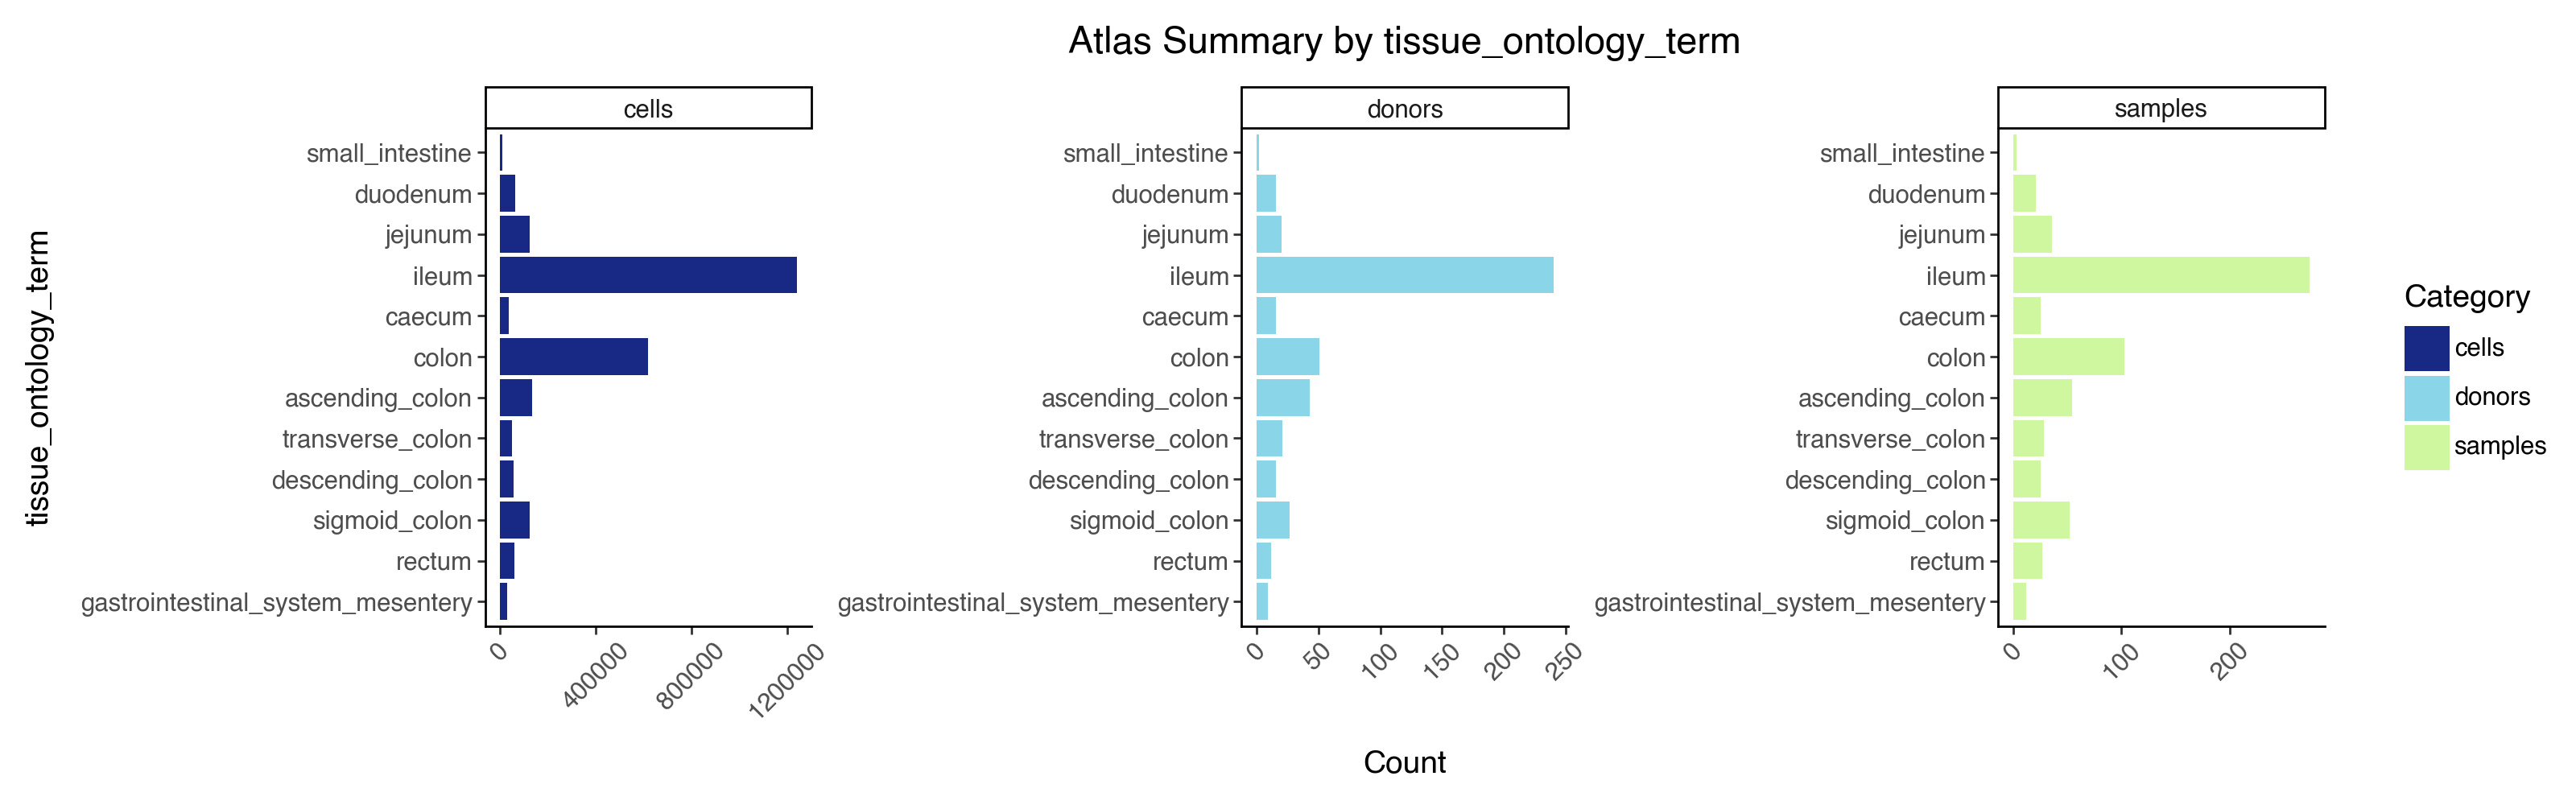

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/January2025_meeting/plots/tissue_ontology_term_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [41]:
from pandas.api.types import CategoricalDtype

group = 'tissue_ontology_term'

custom_order = reversed(['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
                'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
               'rectum', 'gastrointestinal_system_mesentery'])

file_path = f"/Users/kylekimler/Projects/GCA/January2025_meeting/plots/{group}_summary.png"

cat_type = CategoricalDtype(categories=custom_order, ordered=True)

# Convert the DataFrame column to this categorical type
meta[group] = meta[group].astype(cat_type)

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/3501993530.py:25: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


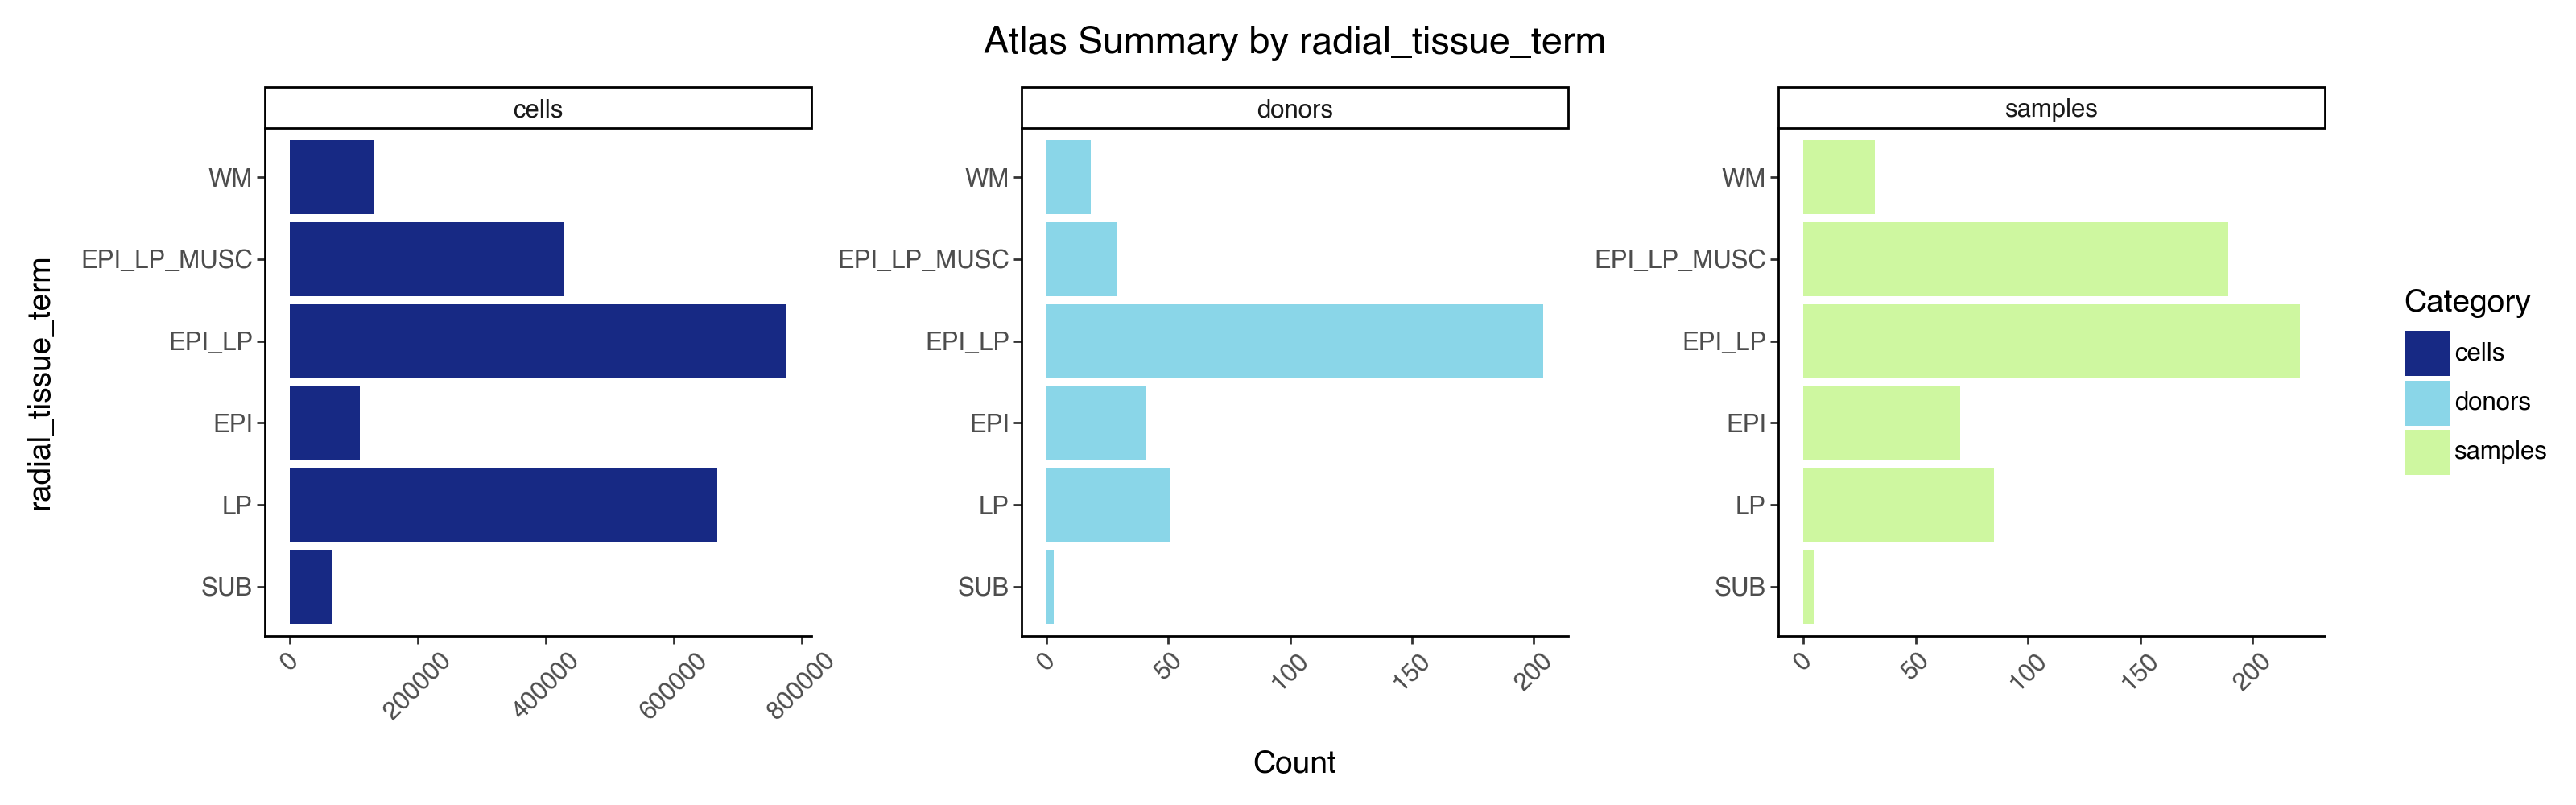

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/January2025_meeting/plots/radial_tissue_term_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [45]:
group = 'radial_tissue_term'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/{group}_summary.png"

custom_order = reversed(['WM', 'EPI_LP_MUSC', 'EPI_LP', 'EPI', 'LP', 'MUSC', 'SUB'])

file_path = f"/Users/kylekimler/Projects/GCA/January2025_meeting/plots/{group}_summary.png"

cat_type = CategoricalDtype(categories=custom_order, ordered=True)

# Convert the DataFrame column to this categorical type
meta[group] = meta[group].astype(cat_type)


# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [46]:
meta['age_range'] = meta['age_range'].astype(str)

age_ranges = meta['age_range'].unique()
sorted_age_ranges = sorted([x for x in age_ranges if x != 'unknown' and '-' in x], key=lambda x: int(x.split('-')[1]))
age_range_type = CategoricalDtype(categories=sorted_age_ranges, ordered=True)
meta['age_range'] = meta['age_range'].astype(age_range_type)


In [47]:
meta['age_range'].value_counts()

age_range
50-59    450438
70-79    410671
60-69    253032
10-19    212870
30-39    179341
80-89    176999
20-29    124412
40-49    100763
0-9       17870
1-5       14215
5-15      12309
90-99      2190
Name: count, dtype: int64

In [48]:
range_mapping = {
    '30-40': '30-39',  # Assuming '30-40' should actually be '30-39'
    '60-70': '60-69',  # Assuming '60-70' should actually be '60-69'
    '70-80': '70-79',  # Assuming '70-80' should actually be '70-79'
    '20-30': '20-29',  # Adjusting '20-29' to '20-30'
    '5-15': '5-14',     # Assuming '5-15' should actually be '5-14'
    '10-14': '5-14'
}

# Replace the age ranges in the DataFrame
meta['age_range'] = meta['age_range'].replace(range_mapping)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/3573755699.py:11: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [49]:
tissue_mapping = {
    'nan': 'colon',  # Assuming '30-40' should actually be '30-39'
}

# Replace the age ranges in the DataFrame
meta['tissue_ontology_term'] = meta['tissue_ontology_term'].replace(tissue_mapping)


In [50]:
meta['age_range'].value_counts()

age_range
50-59    450438
70-79    410671
60-69    253032
10-19    212870
30-39    179341
80-89    176999
20-29    124412
40-49    100763
0-9       17870
1-5       14215
5-14      12309
90-99      2190
Name: count, dtype: int64

In [51]:
meta['development_stage_ontology_term_id'].value_counts()

development_stage_ontology_term_id
unknown           490203
HsapDv:0000240    390950
HsapDv:0000242    323544
HsapDv:0000243    161139
HsapDv:0000241    134405
HsapDv:0000087    127105
HsapDv:000241      65444
HsapDv:0000238     61569
HsapDv:0000264     61297
HsapDv:0000268     59496
HsapDv:0000239     58076
HsapDv:000240      53577
HsapDv:000239      42687
HsapDv:0000237     40724
HsapDv:000242      34911
HsapDv:000243      15860
HsapDv:000237      11394
HsapDv:000238       2906
HsapDv:0000244      2190
HsapDv:0000111      1667
HsapDv:0000110      1353
HsapDv:0000103       687
HsapDv:0000149       547
Name: count, dtype: int64

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/3759566222.py:16: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


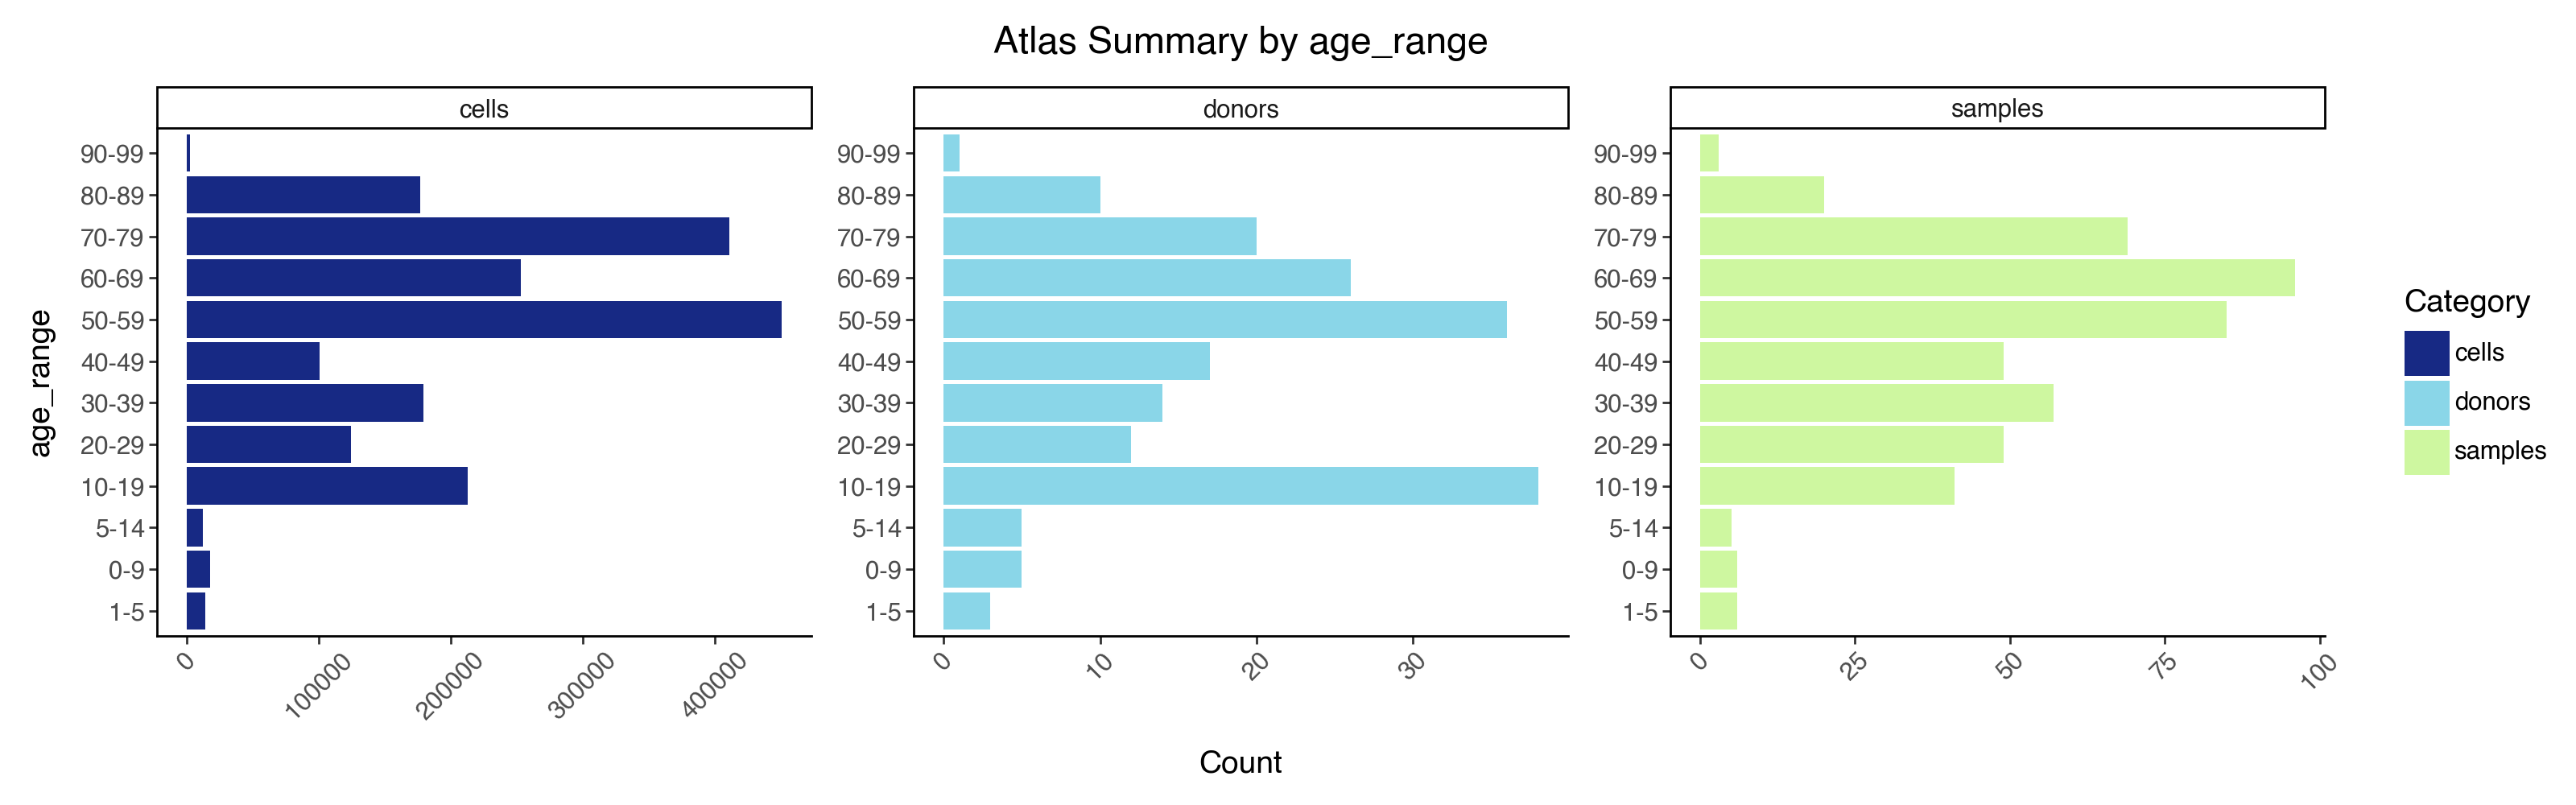

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/age_range_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [52]:
group = 'age_range'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/{group}_summary.png"


# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [53]:
group = 'age_range'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

pal = [
    # Blue/Turquoise Tones - small intestine
    '#8AD6E8', '#1D7874', '#172984', '#34C0C0',
    # Red/Pink/Orange Tones - large intestine
    '#E56399', '#F45B69', '#DA4167', '#EDC7CF', '#F08700', '#D17B0F', '#CEF7A0',
    # Neutral/Grey - mesentery
    '#5B6C5D'
]
tissue_order = reversed(['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
                'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
               'rectum', 'gastrointestinal_system_mesentery'])

meta['tissue_ontology_term'] = meta['tissue_ontology_term'].str.replace('COLON', 'colon', case=False)




## See bottom of notebook for best age-range/tissue section plots

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


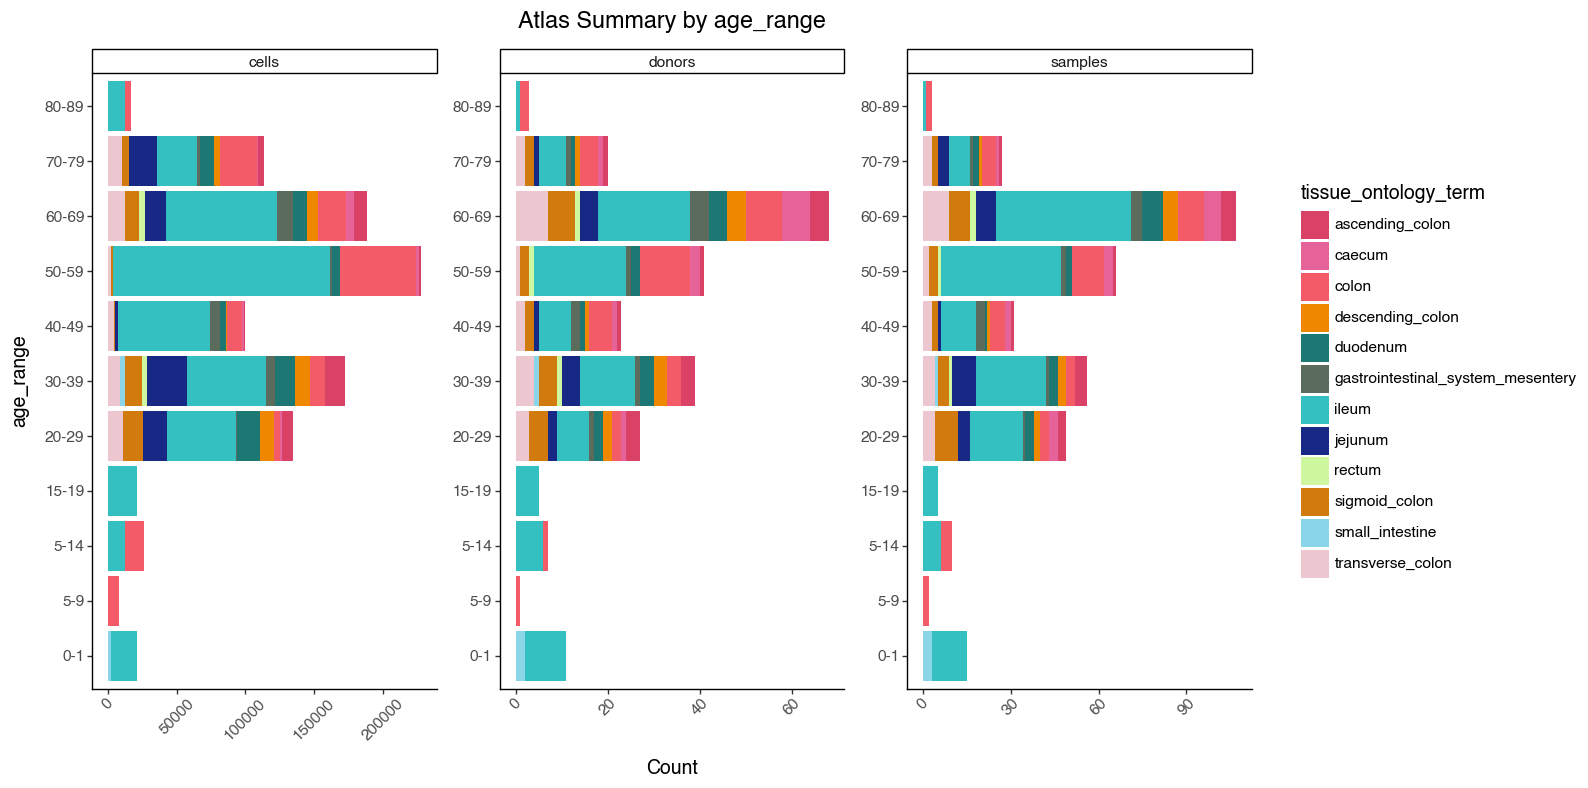

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_71987/2864522101.py:50: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


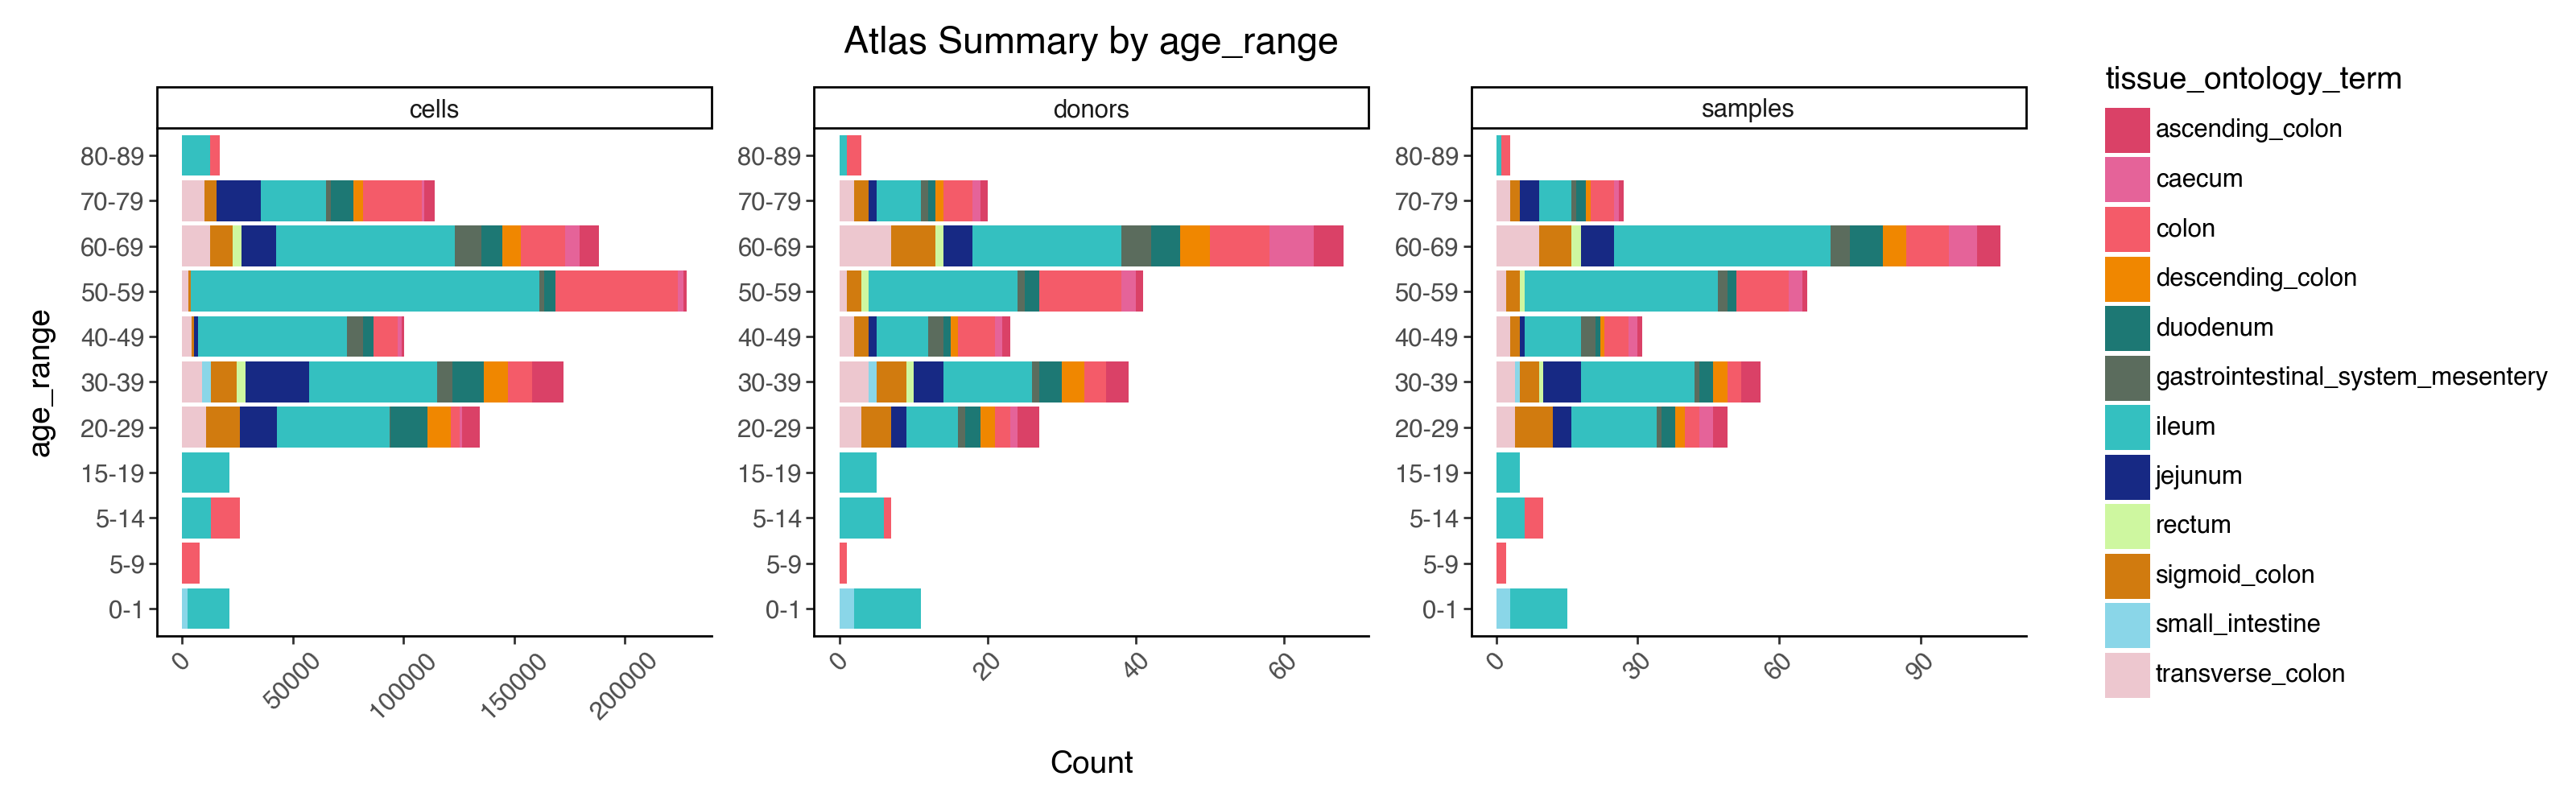

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/June2024_meeting/plots/tissue_age_range_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [63]:
############

from plotnine import (
    ggplot, aes, geom_bar, coord_flip, facet_wrap, theme_classic, 
    element_text, theme, scale_fill_manual, labs
)

# special function for ordered, grouped colors

def create_faceted_bar_graph(df, grouping_var, color_palette, stacking_var=None):
    # Ensure tissue_order is correctly set and matches the color palette length
    tissue_order = ['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
                    'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
                    'rectum', 'gastrointestinal_system_mesentery']

    # Compute summary statistics per group
    if stacking_var:
        df[stacking_var] = df[stacking_var].astype(str)
        summary_df = df.groupby([grouping_var, stacking_var], observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')  # Assuming 'cell_id' is the index or a column in .obs
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var, stacking_var],
                                    var_name='Category', value_name='Count')

        # Plot with stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill=stacking_var))
            + geom_bar(stat='identity', position='stack')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5),
                axis_text_y=element_text(hjust=1),
                legend_position='right',
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))
            + scale_fill_manual(values=dict(zip(tissue_order, color_palette)))  # Assign colors explicitly
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    return p

# Example usage
plot = create_faceted_bar_graph(meta, 'age_range', pal, 'tissue_ontology_term')
plot.draw(show=True)

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)

In [54]:
import pandas as pd
from plotnine import ggplot, aes, geom_bar, coord_flip, facet_wrap, theme_classic, element_text, theme, scale_fill_manual, labs, facet_grid

def create_faceted_bar_graph(df, grouping_var, color_palette, stacking_var=None, stacking_values=None):
    # Compute summary statistics per group
    if stacking_var:
        df[stacking_var] = df[stacking_var].astype(str)
        summary_df = df.groupby([grouping_var, stacking_var], observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')  # Assuming 'cell_id' is the index or a column in .obs
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var, stacking_var],
                                    var_name='Category', value_name='Count')

        # melted_df[stacking_var] = pd.Categorical(melted_df[stacking_var], categories=stacking_values)

        # Add a new column to identify records that fall within the stacking_values or outside it
        # melted_df['Group'] = melted_df[stacking_var].apply(lambda x: 'Not in integration' if x in stacking_values else 'In integration')

        # Plot with stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill=stacking_var))
            + geom_bar(stat='identity', position='stack')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5),
                axis_text_y=element_text(hjust=1),
                legend_position='right',
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))
            + scale_fill_manual(values=color_palette, limits = stacking_values, breaks = stacking_values)  # Directly use provided color palette
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    else:
        summary_df = df.groupby(grouping_var, observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var],
                                    var_name='Category', value_name='Count')

        # Plot without stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill='Category'))
            + geom_bar(stat='identity', position='dodge')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5), 
                axis_text_y=element_text(hjust=1),  # Justify y-axis labels
                legend_position='right', 
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))  # Adjust figure size for long labels
            + scale_fill_manual(values=color_palette)
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    # Remove y-axis tick labels for the second and third facets
    p = p + theme(
        strip_text_y=element_blank()
    )

    return p



/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/2171250347.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


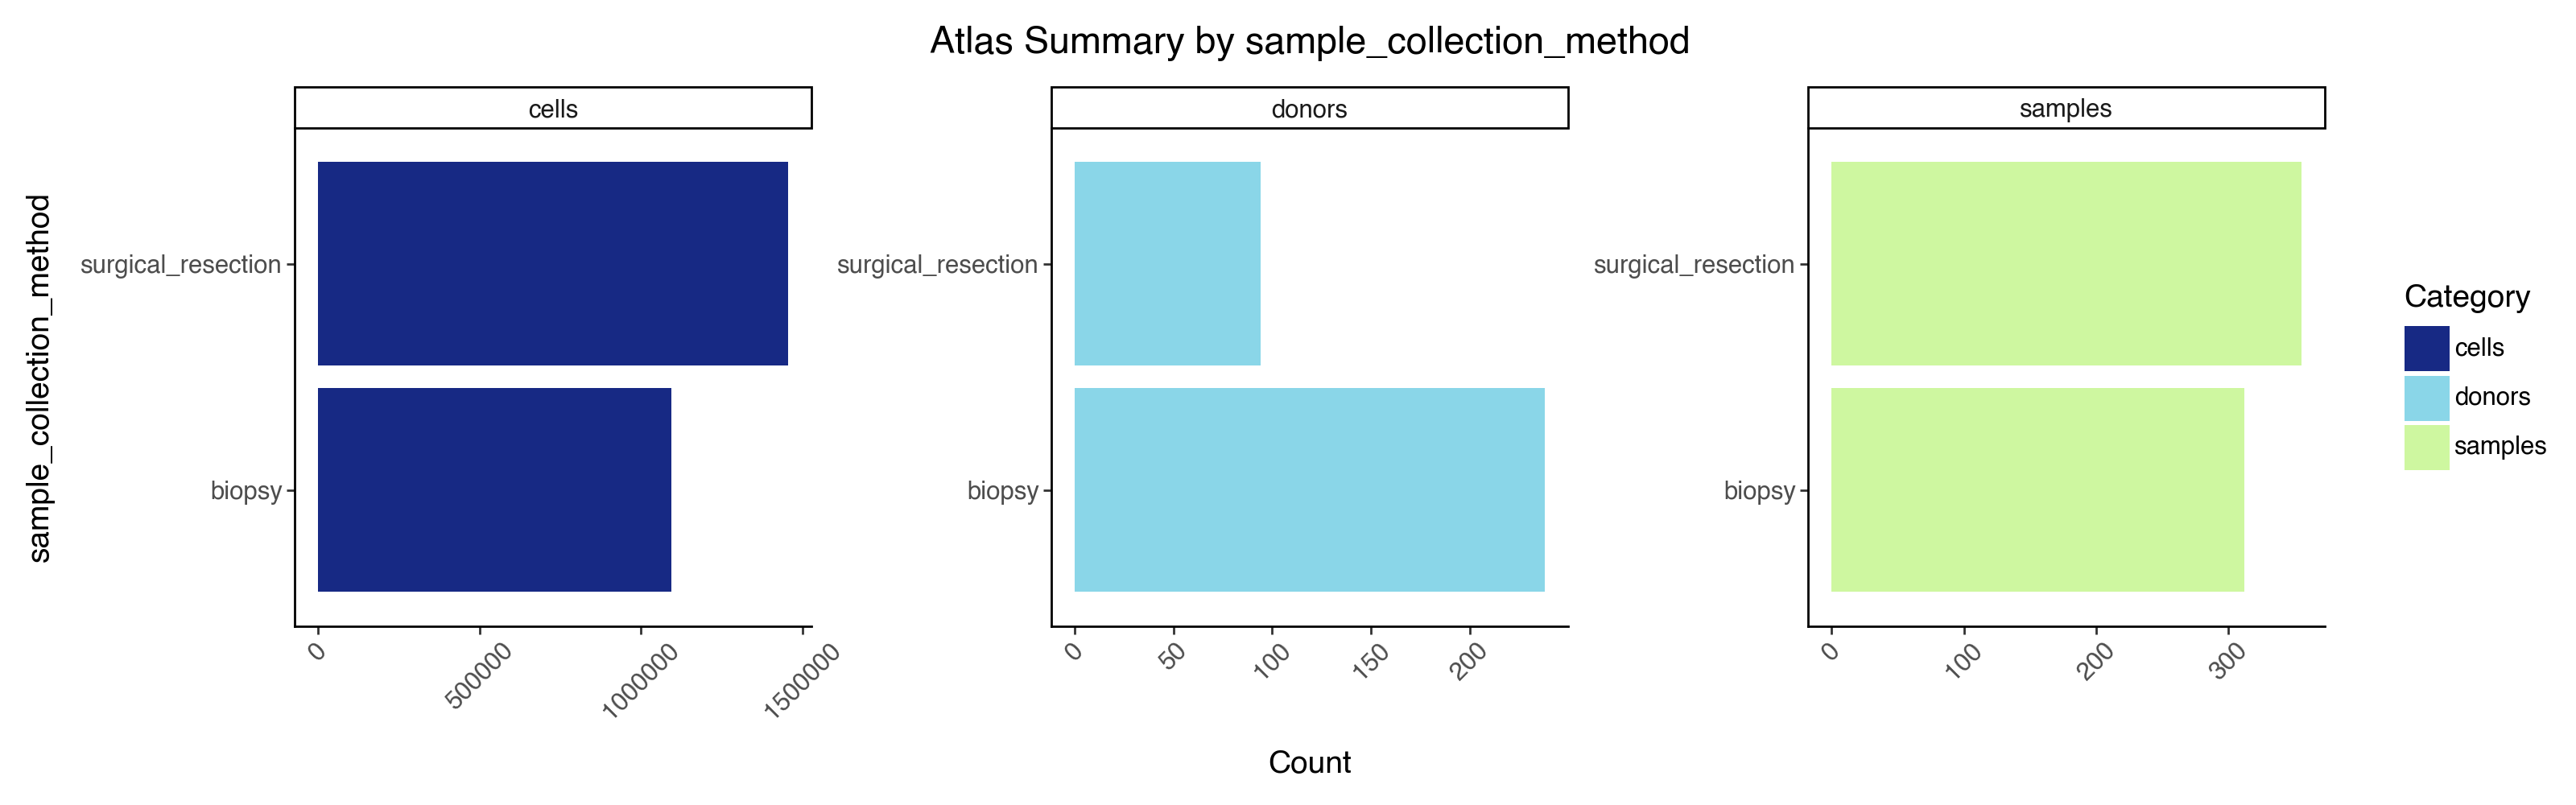

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/sample_collection_method_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [55]:
group = 'sample_collection_method'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [70]:
meta['sampled_site_condition']

cell_id
AAACCTGAGAAAGTGG-1-0-0-0              healthy
AAACCTGAGCCACCTG-1-0-0-0              healthy
AAACCTGAGCGCTCCA-1-0-0-0              healthy
AAACCTGAGCTCCCAG-1-0-0-0              healthy
AAACCTGAGCTGAAAT-1-0-0-0              healthy
                                       ...   
TTTGTCAGTACAGTGG-HT-188-Adult-Duo    adjacent
TTTGTCAGTATATGAG-HT-188-Adult-Duo    adjacent
TTTGTCAGTCCAGTAT-HT-188-Adult-Duo    adjacent
TTTGTCATCATTGCCC-HT-188-Adult-Duo    adjacent
TTTGTCATCTCGCATC-HT-188-Adult-Duo    adjacent
Name: sampled_site_condition, Length: 1267745, dtype: object

In [71]:
def adjust_condition(row):
    if row['sampled_site_condition'] == 'LP':
        return 'adjacent' if row['disease_free_text'] != 'Healthy' else 'Healthy'
    return row['sampled_site_condition']

meta['sampled_site_condition'] = meta.apply(adjust_condition, axis=1)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/2527021510.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


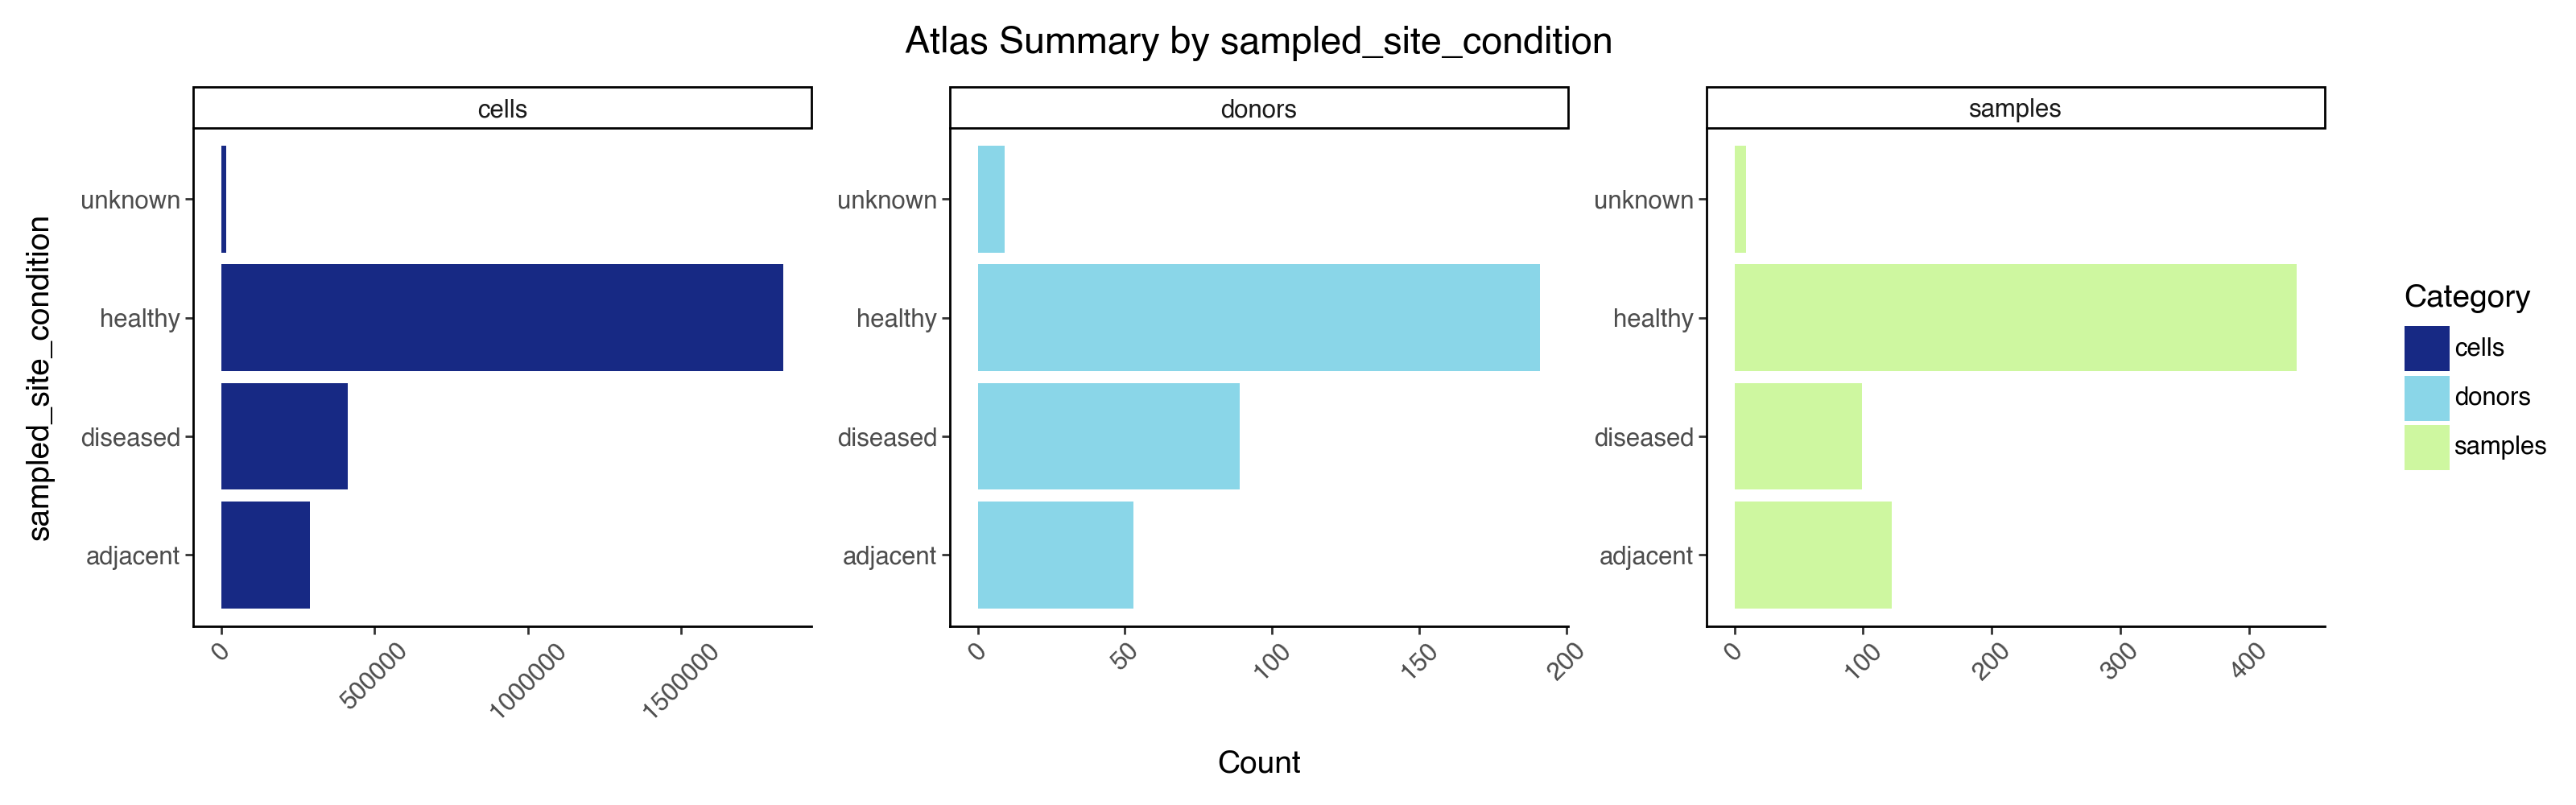

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/sampled_site_condition_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [56]:
group = 'sampled_site_condition'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [57]:
group = 'disease_free_text'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 25
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


KeyError: 'disease_free_text'

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/668770496.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


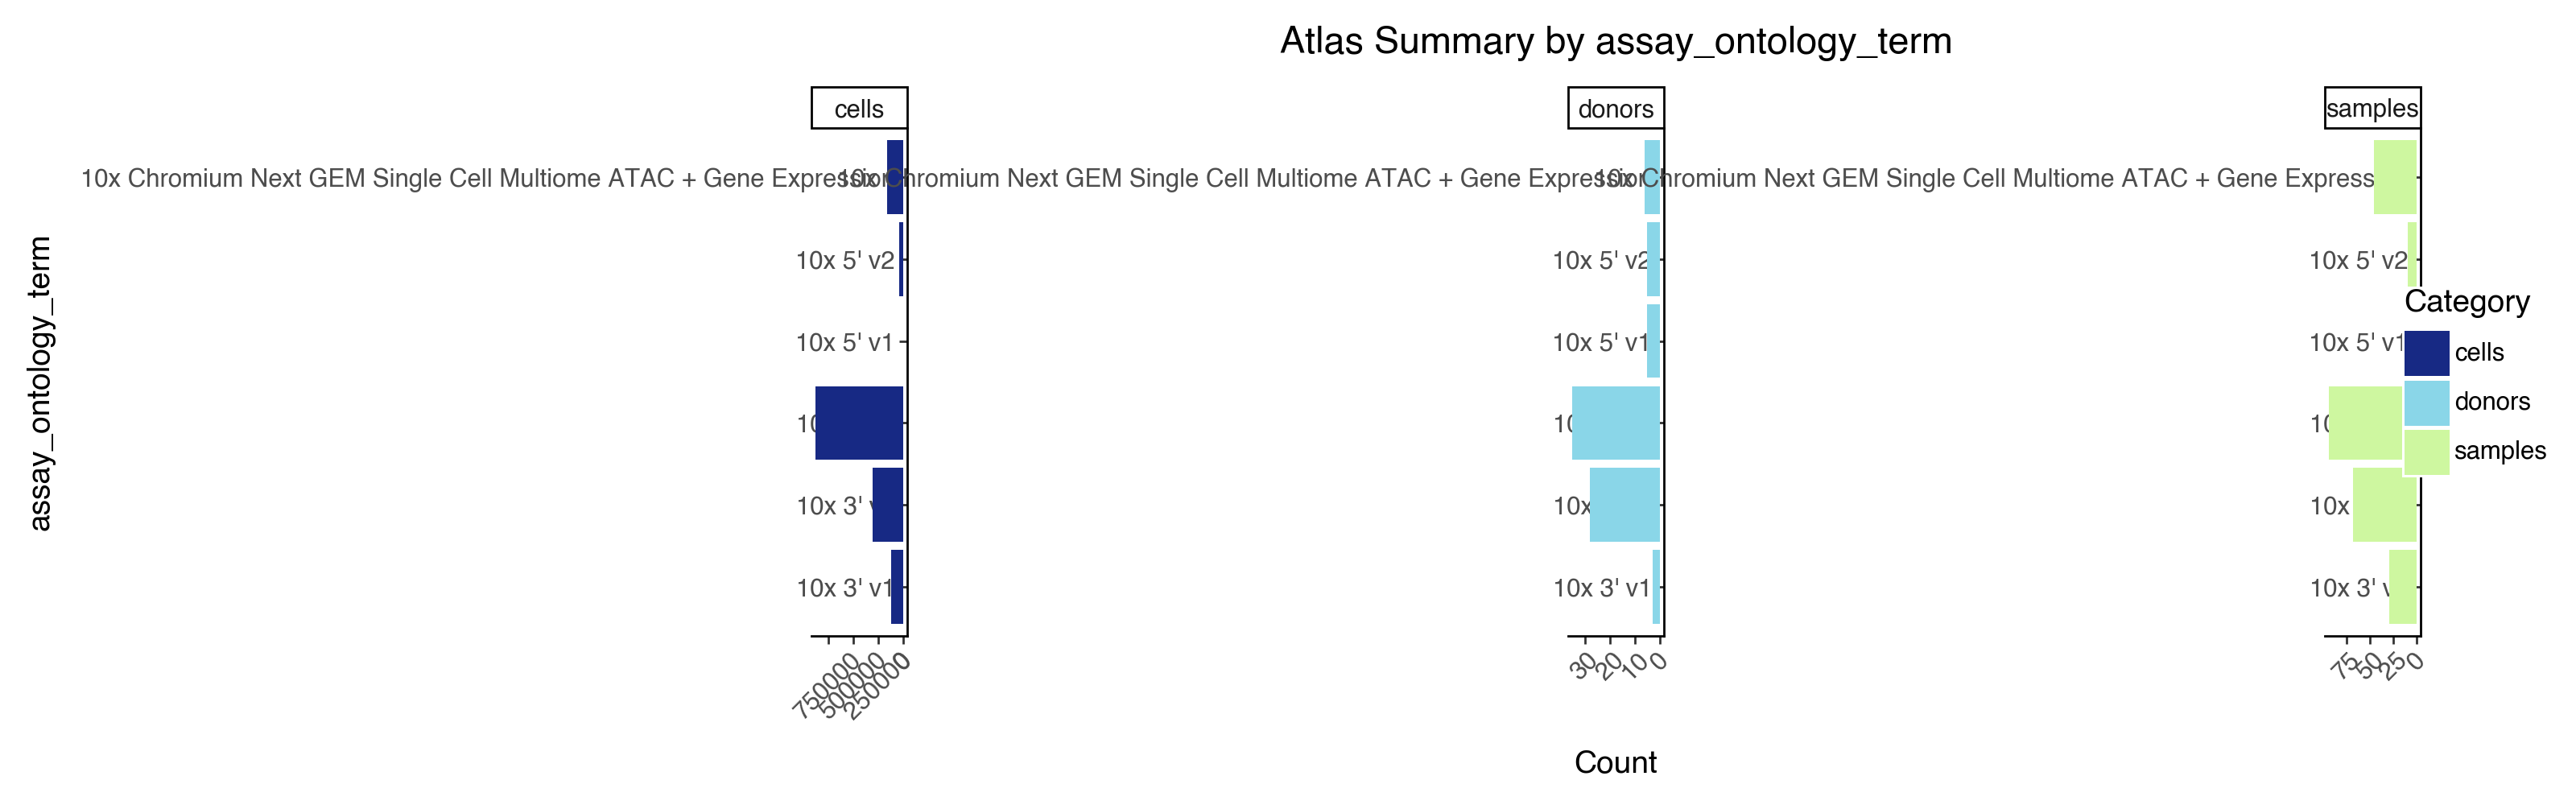

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/assay_ontology_term_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [58]:
group = 'assay_ontology_term'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/1129336560.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


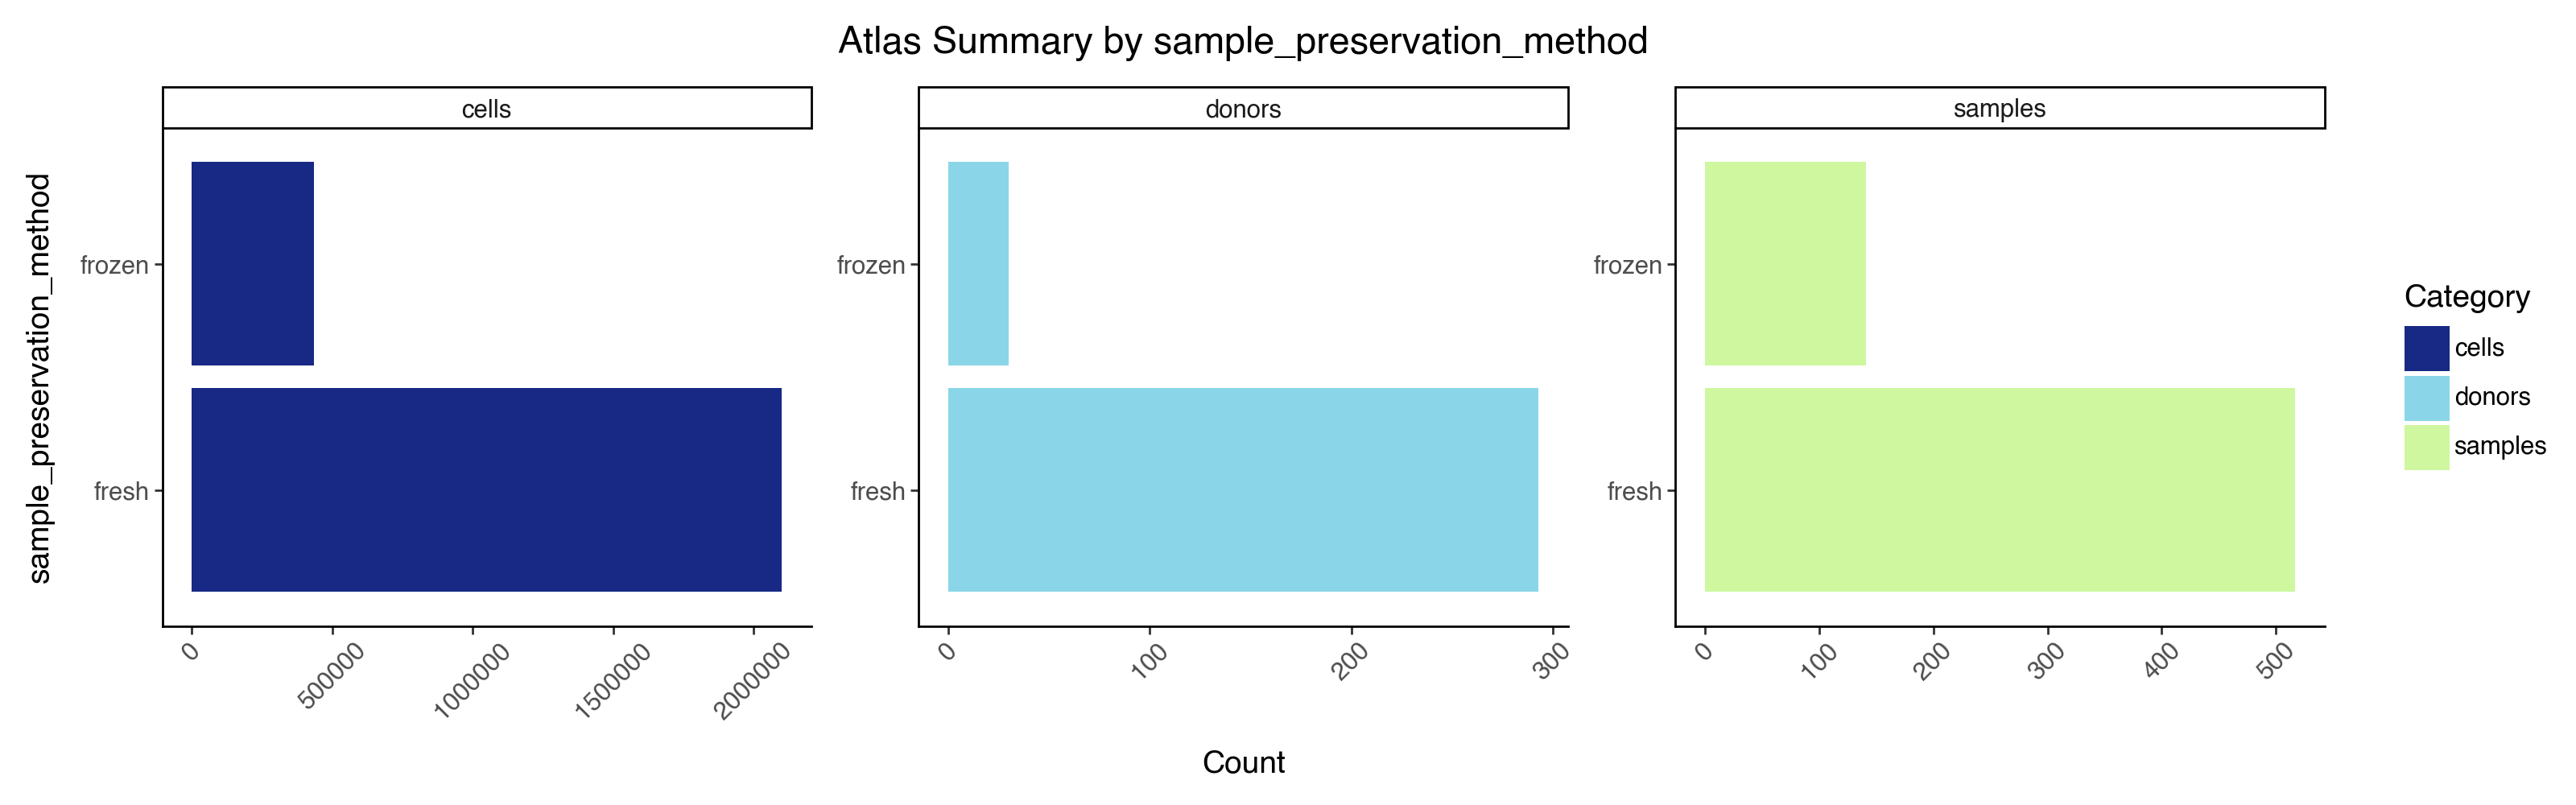

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/sample_preservation_method_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [59]:
group = 'sample_preservation_method'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [60]:
pal = [
    # Blue/Turquoise Tones - small intestine
    '#00A6D6',  # A stronger, more vivid blue
    '#1D4F91',  # Deep blue, less harsh than original
    '#27A0A3',  # Muted turquoise
    '#A8E6CF',  # Soft mint green for contrast
    '#00E6CF',  # straight up cyan
    
    # Red/Pink/Orange Tones - large intestine
    '#F8BBD0',  # Soft pink for lighter contrast
    '#E74C3C',  # Vivid red for emphasis
    '#F39C6B',  # Soft coral
    '#D1495B',  # Deep crimson for depth
    '#E27D60',  # Muted orange-pink
    '#F39C12',  # Warm orange, brighter but less harsh than #D17B0F

    # Neutral/Grey - mesentery
    '#666666',  # Medium grey, less harsh and easier on the eyes
]


# Correct ordering of tissue levels
tissue_order = list(['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
                'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
               'rectum', 'gastrointestinal_system_mesentery'])

meta['tissue_ontology_term'] = meta['tissue_ontology_term'].str.replace('COLON', 'colon', case=False)


In [61]:
def clean_age_ranges(age_range):
    # Randomly assign "5-15" to either "0-9" or "10-19"
    if age_range == "5-15":
        return np.random.choice(["0-9", "10-19"])
    # Assign other overlapping ranges to appropriate buckets
    elif age_range == "5-9":
        return "0-9"
    elif age_range == "10-14":
        return "10-19"
    elif age_range == "1-5":
        return "0-9"
    # Keep existing decade-wide ranges unchanged
    else:
        return age_range

# Apply the function to the 'age_range' column in meta
meta['age_range'] = meta['age_range'].apply(clean_age_ranges)


In [62]:
import pandas as pd
from plotnine import ggplot, aes, geom_bar, coord_flip, facet_wrap, theme_classic, element_text, theme, scale_fill_manual, labs

def create_faceted_bar_graph(df, grouping_var, color_palette, stacking_var=None, stacking_values=None):
    # Convert stacking variable to categorical with a specific order
    if stacking_var:
        df[stacking_var] = pd.Categorical(df[stacking_var], categories=stacking_values, ordered=True)
        
        # Compute summary statistics per group
        summary_df = df.groupby([grouping_var, stacking_var], observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')  # Assuming 'cell_id' is the index or a column in .obs
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var, stacking_var],
                                    var_name='Category', value_name='Count')

        # Plot with stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill=stacking_var))
            + geom_bar(stat='identity', position='stack')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5),
                axis_text_y=element_text(hjust=1),
                legend_position='right',
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))
            + scale_fill_manual(values=color_palette, limits=stacking_values, breaks=stacking_values)  # Directly use provided color palette
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    else:
        summary_df = df.groupby(grouping_var, observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var],
                                    var_name='Category', value_name='Count')

        # Plot without stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill='Category'))
            + geom_bar(stat='identity', position='dodge')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5), 
                axis_text_y=element_text(hjust=1),  # Justify y-axis labels
                legend_position='right', 
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))  # Adjust figure size for long labels
            + scale_fill_manual(values=color_palette)
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    # Remove y-axis tick labels for the second and third facets
    p = p + theme(
        strip_text_y=element_blank()
    )

    return p

group = 'age_range'

file_path = f"/Users/kylekimler/Projects/GCA/January2025_meeting/plots/tissue_{group}_summary.png"

pal = [
    # Blue/Turquoise Tones - small intestine
    '#00A6D6',  # A stronger, more vivid blue
    '#1D4F91',  # Deep blue, less harsh than original
    '#27A0A3',  # Muted turquoise
    '#A8E6CF',  # Soft mint green for contrast
    '#00E6CF',  # straight up cyan
    
    # Red/Pink/Orange Tones - large intestine
    '#F8BBD0',  # Soft pink for lighter contrast
    '#E74C3C',  # Vivid red for emphasis
    '#F39C6B',  # Soft coral
    '#D1495B',  # Deep crimson for depth
    '#E27D60',  # Muted orange-pink
    '#F39C12',  # Warm orange, brighter but less harsh than #D17B0F

    # Neutral/Grey - mesentery
    '#666666',  # Medium grey, less harsh and easier on the eyes
]




/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/927900904.py:18: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


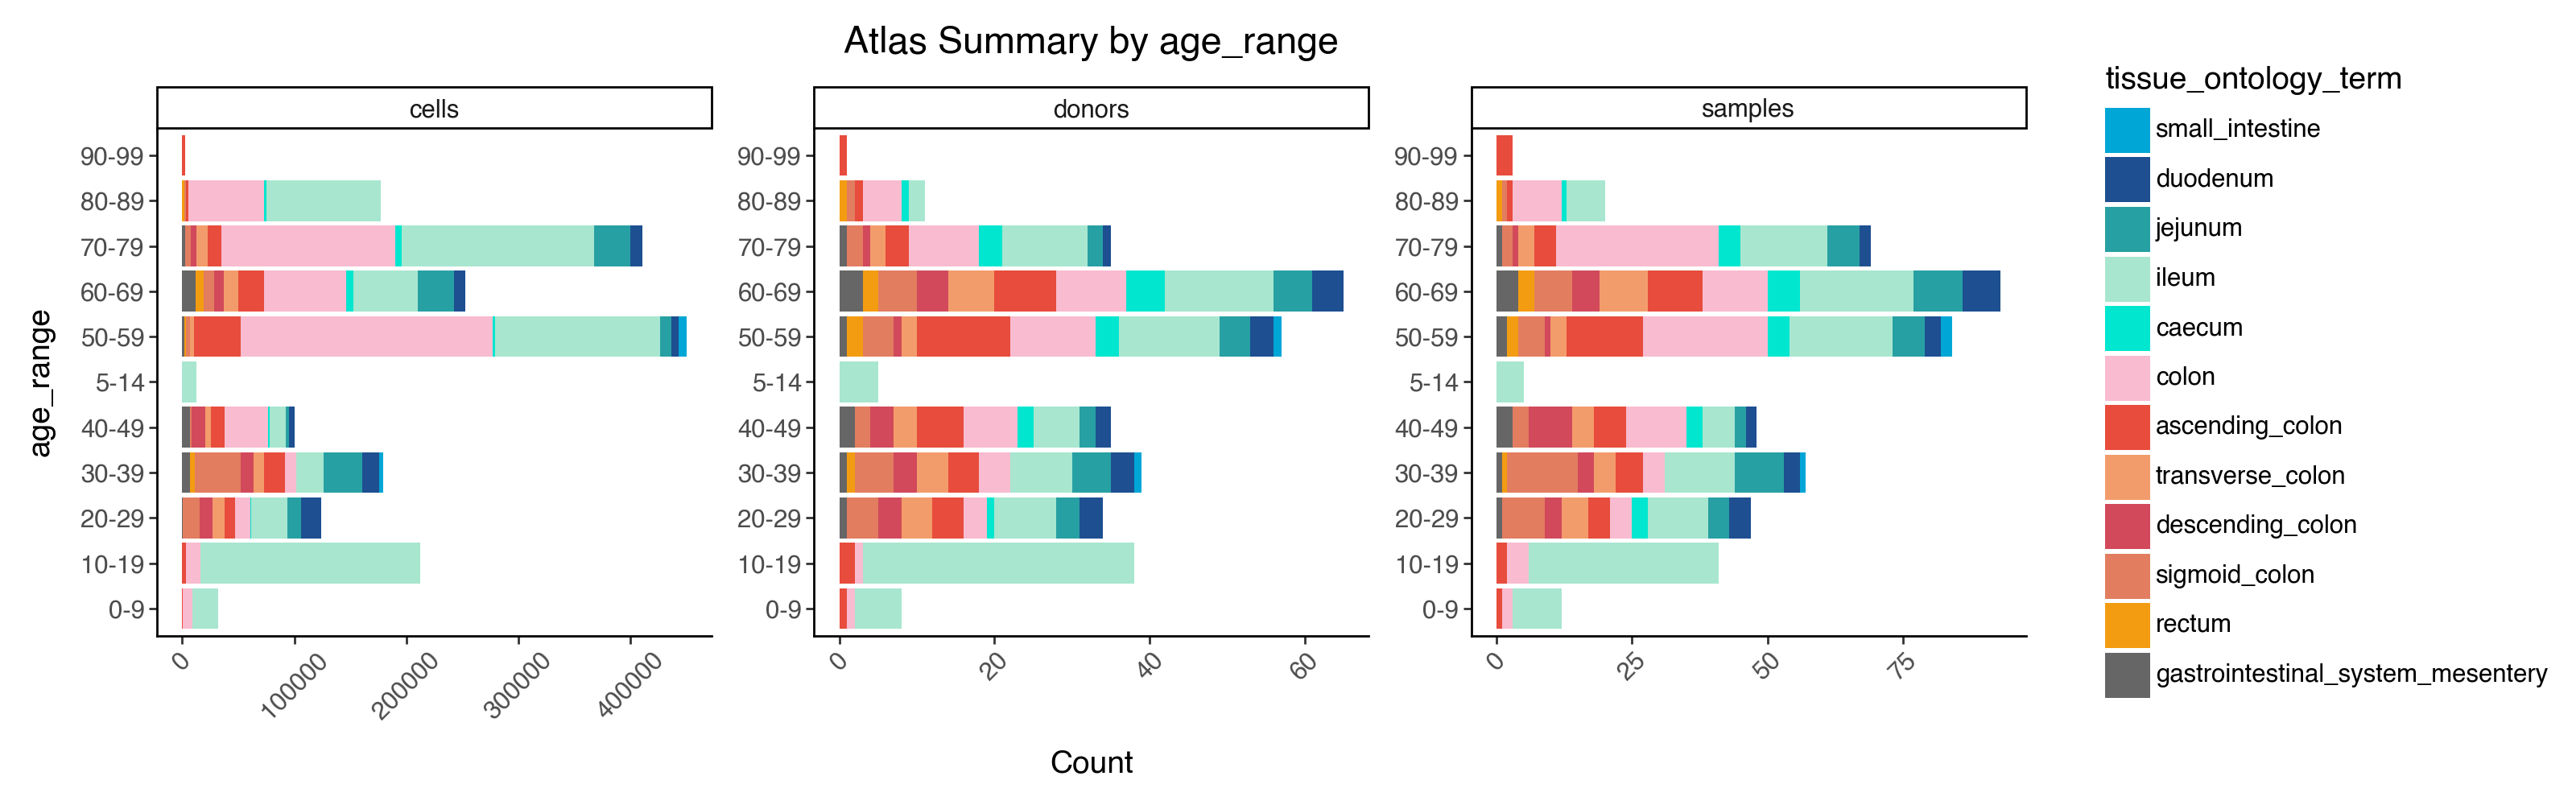

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/January2025_meeting/plots/tissue_age_range_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [63]:
# Correct ordering of tissue levels
tissue_order = list(['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
                'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
               'rectum', 'gastrointestinal_system_mesentery'])

meta['tissue_ontology_term'] = meta['tissue_ontology_term'].str.replace('COLON', 'colon', case=False)

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/3609847814.py:13: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


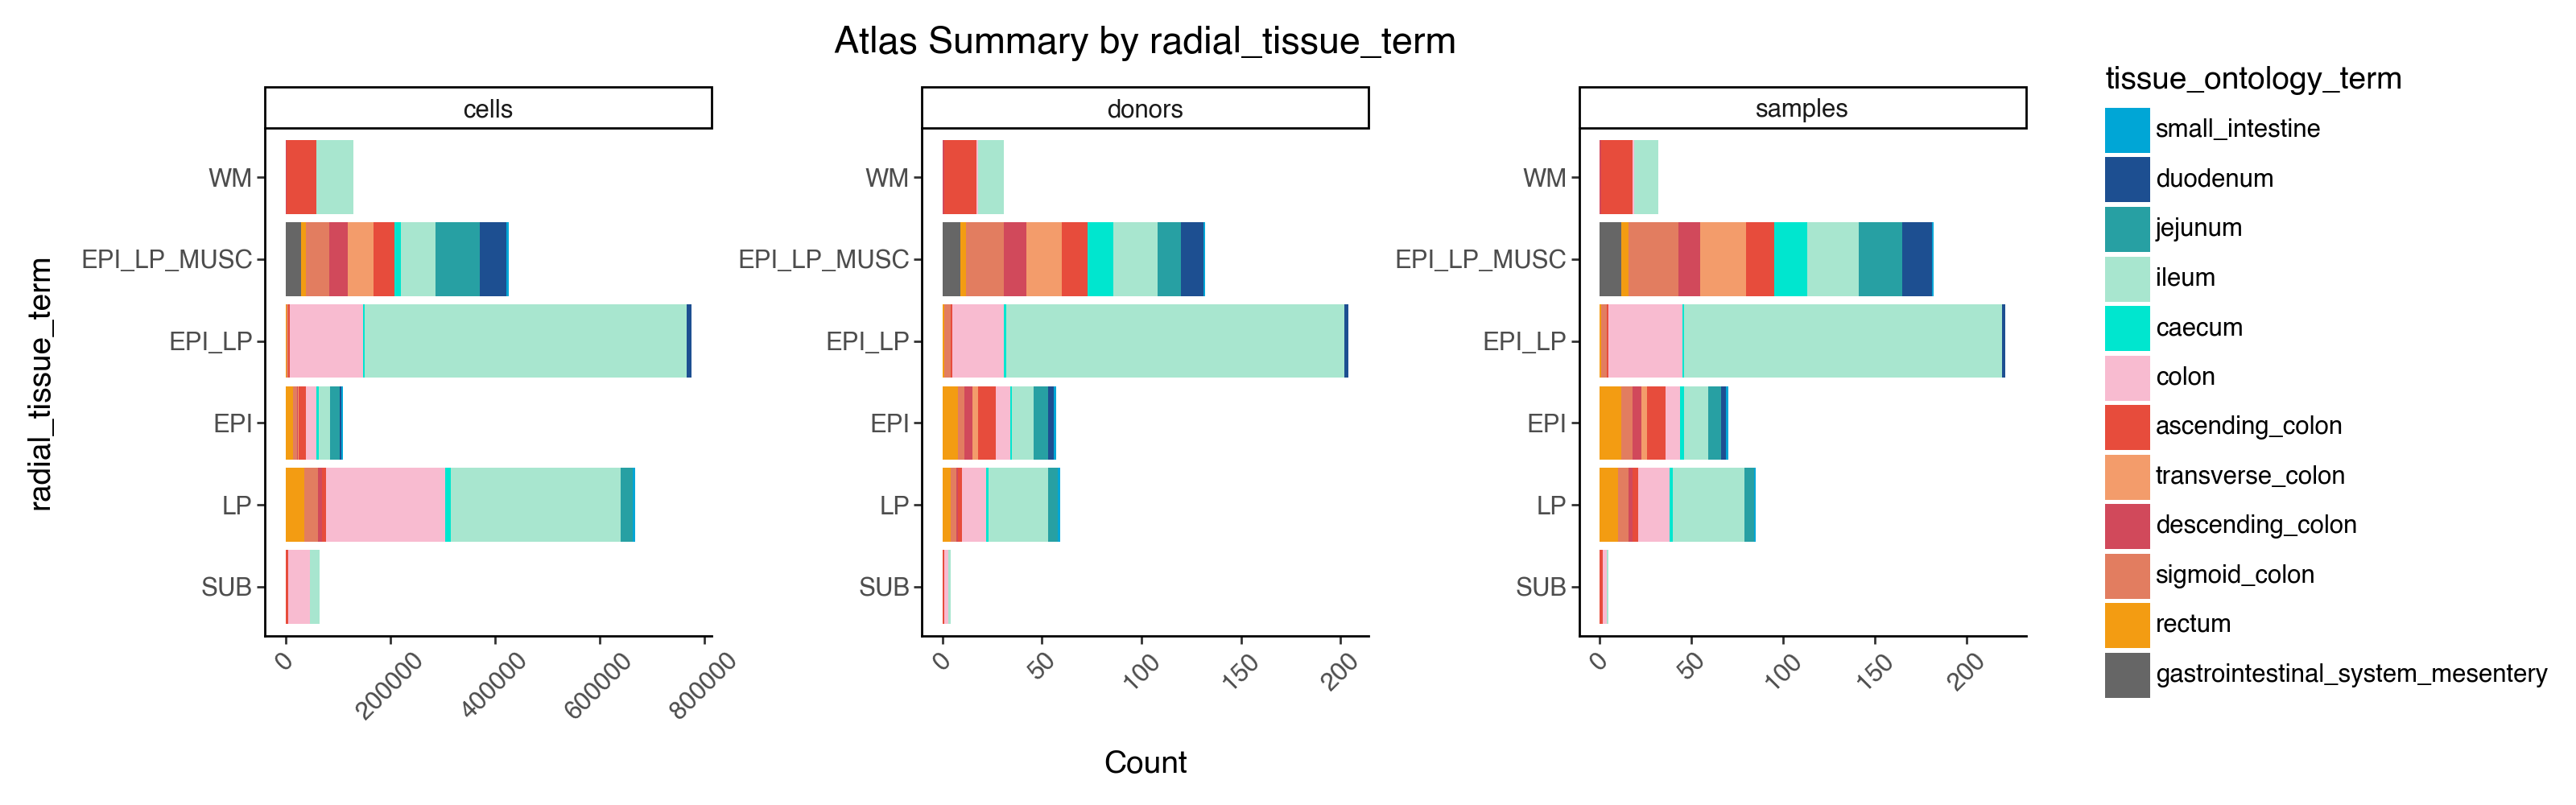

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_radial_tissue_term_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [65]:
group = 'radial_tissue_term'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )
wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [66]:
meta.columns

Index(['CellID', 'dataset_id', 'donor_id', 'sample_id', 'author_cell_type',
       'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text',
       'sample_source', 'sample_collection_method', 'tissue_type',
       'sampled_site_condition', 'disease_ontology_term',
       'disease_ontology_term_id', 'sample_preservation_method',
       'suspension_type', 'is_primary_data', 'age_range',
       'development_stage_ontology_term_id', 'radial_tissue_term',
       'dissociation_protocol', 'cell_enrichment', 'sample_collection_year',
       'library_id', 'library_id_repository', 'library_preparation_batch',
       'library_sequencing_run', 'sample_collection_site',
       'sample_collection_relative_time_point', 'cell_number_loaded',
       'cell_viability_percentage', 'institute', 'author_batch_notes',
       'organism_ontology_term_id', 'manner_of_death', 'sex_ontology_term',
       'sex_ontology_term_id', 'age_at_biopsy', 'consortia', 'study_pi',
       'contact_email', 'batch

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/3480270298.py:13: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


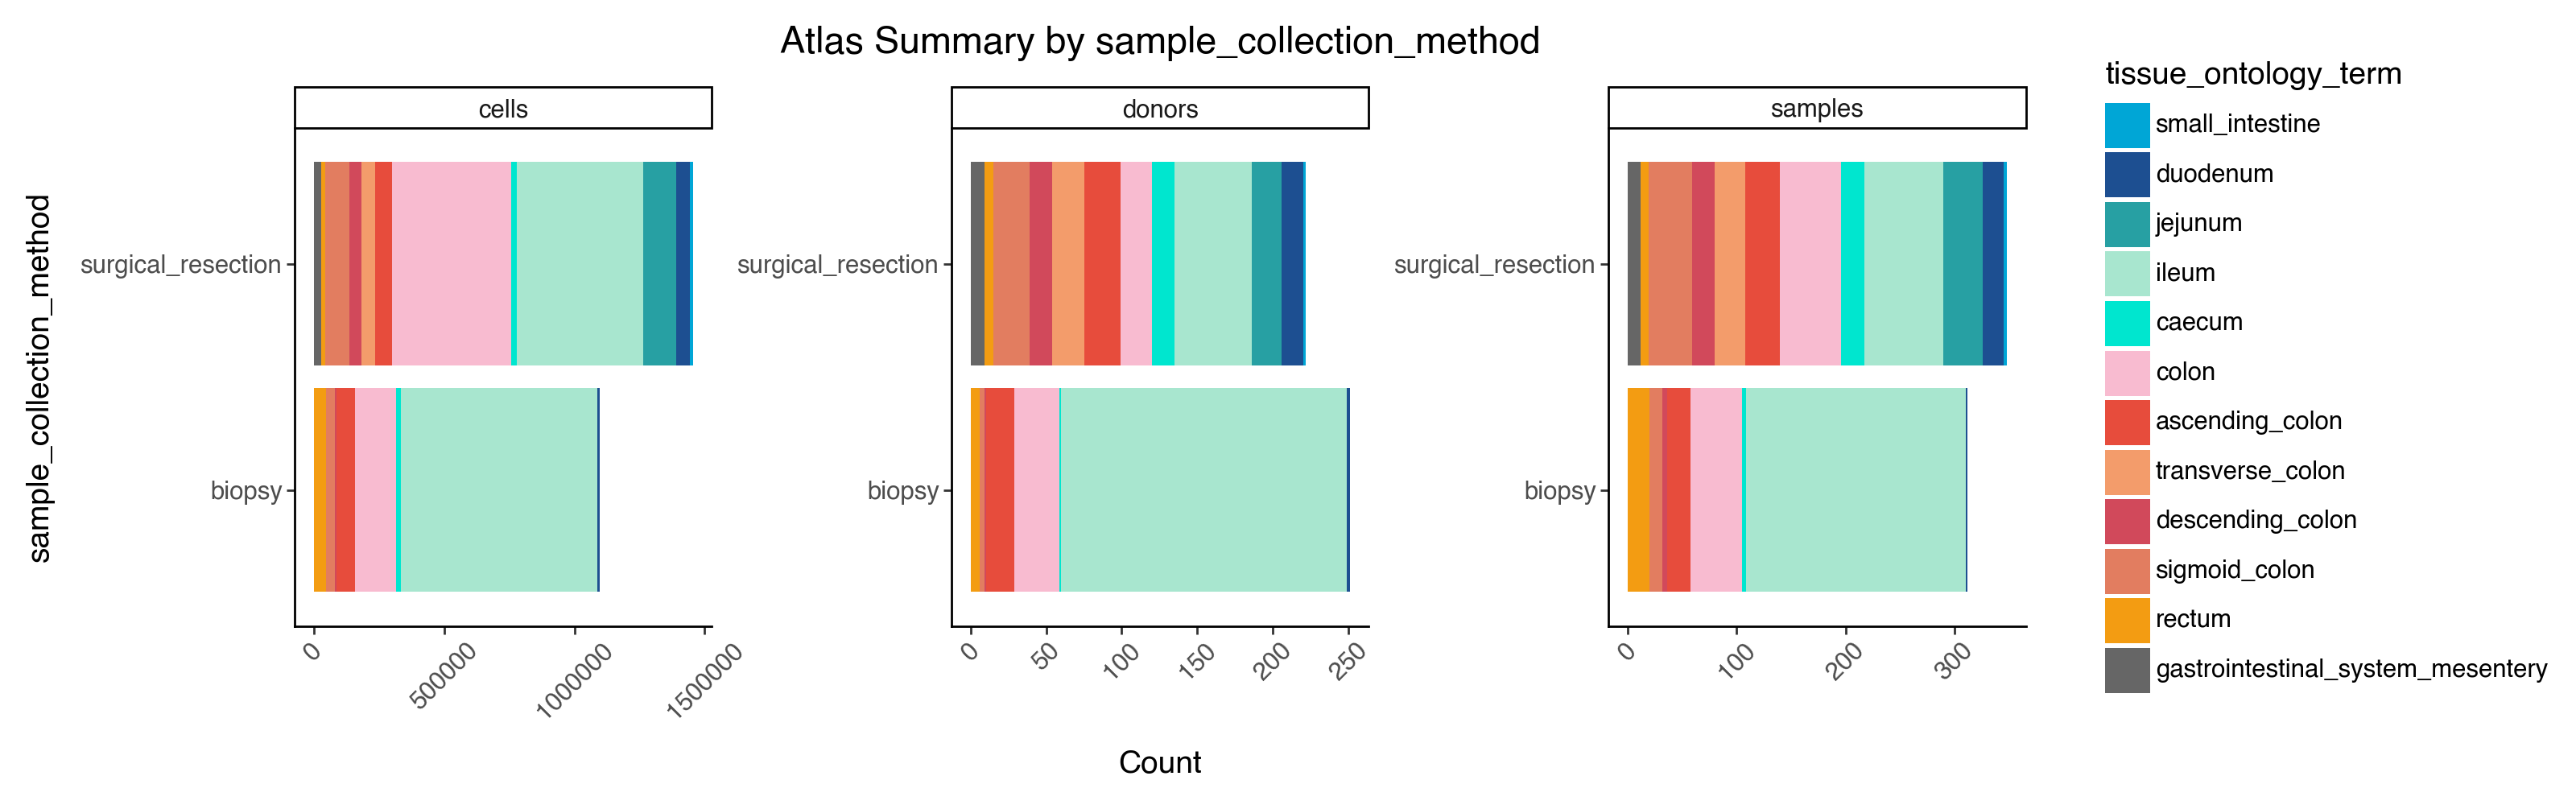

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_sample_collection_method_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [67]:
group = 'sample_collection_method'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )
wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/2374619873.py:13: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


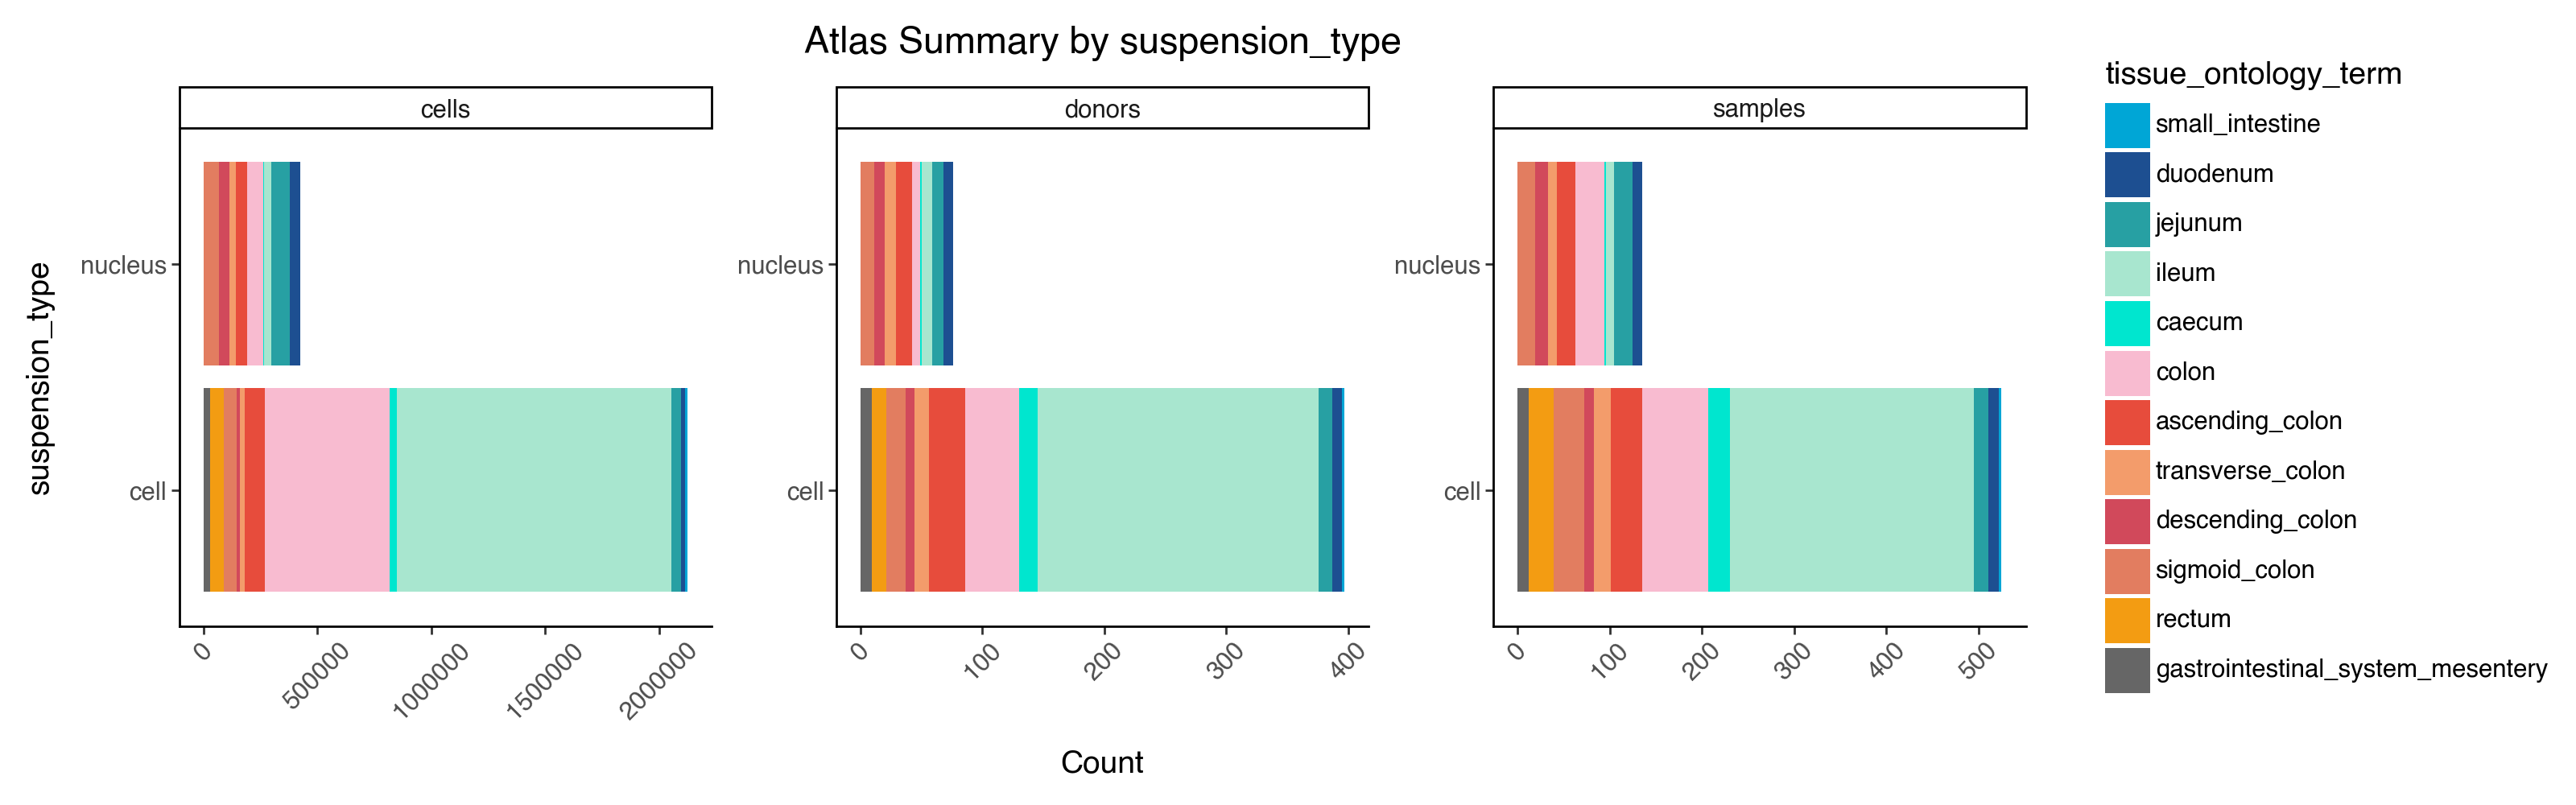

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_suspension_type_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [68]:
group = 'suspension_type'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )
wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [44]:
meta[['dataset_id','sampled_site_condition']].value_counts()

dataset_id        sampled_site_condition
Kong2023          adjacent                  288067
Krzak2023         diseased                  253254
                  healthy                   188658
multiome          healthy                   164146
Drokhylansky2020  adjacent                  151011
Egozi2023         adjacent                  135492
snRNAseq          healthy                   115965
Zheng2024         diseased                  107432
Maddipatla2023    diseased                  103508
Zheng2024         healthy                    89849
Kong2023          diseased                   86230
Luoma2020         healthy                    71039
Kong2023          healthy                    56606
Smillie2019       adjacent                   55909
Luoma2020         diseased                   54224
Nowicki2021       diseased                   50569
Smillie2019       diseased                   43620
Boland2020        diseased                   42982
                  healthy                

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/769765780.py:13: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


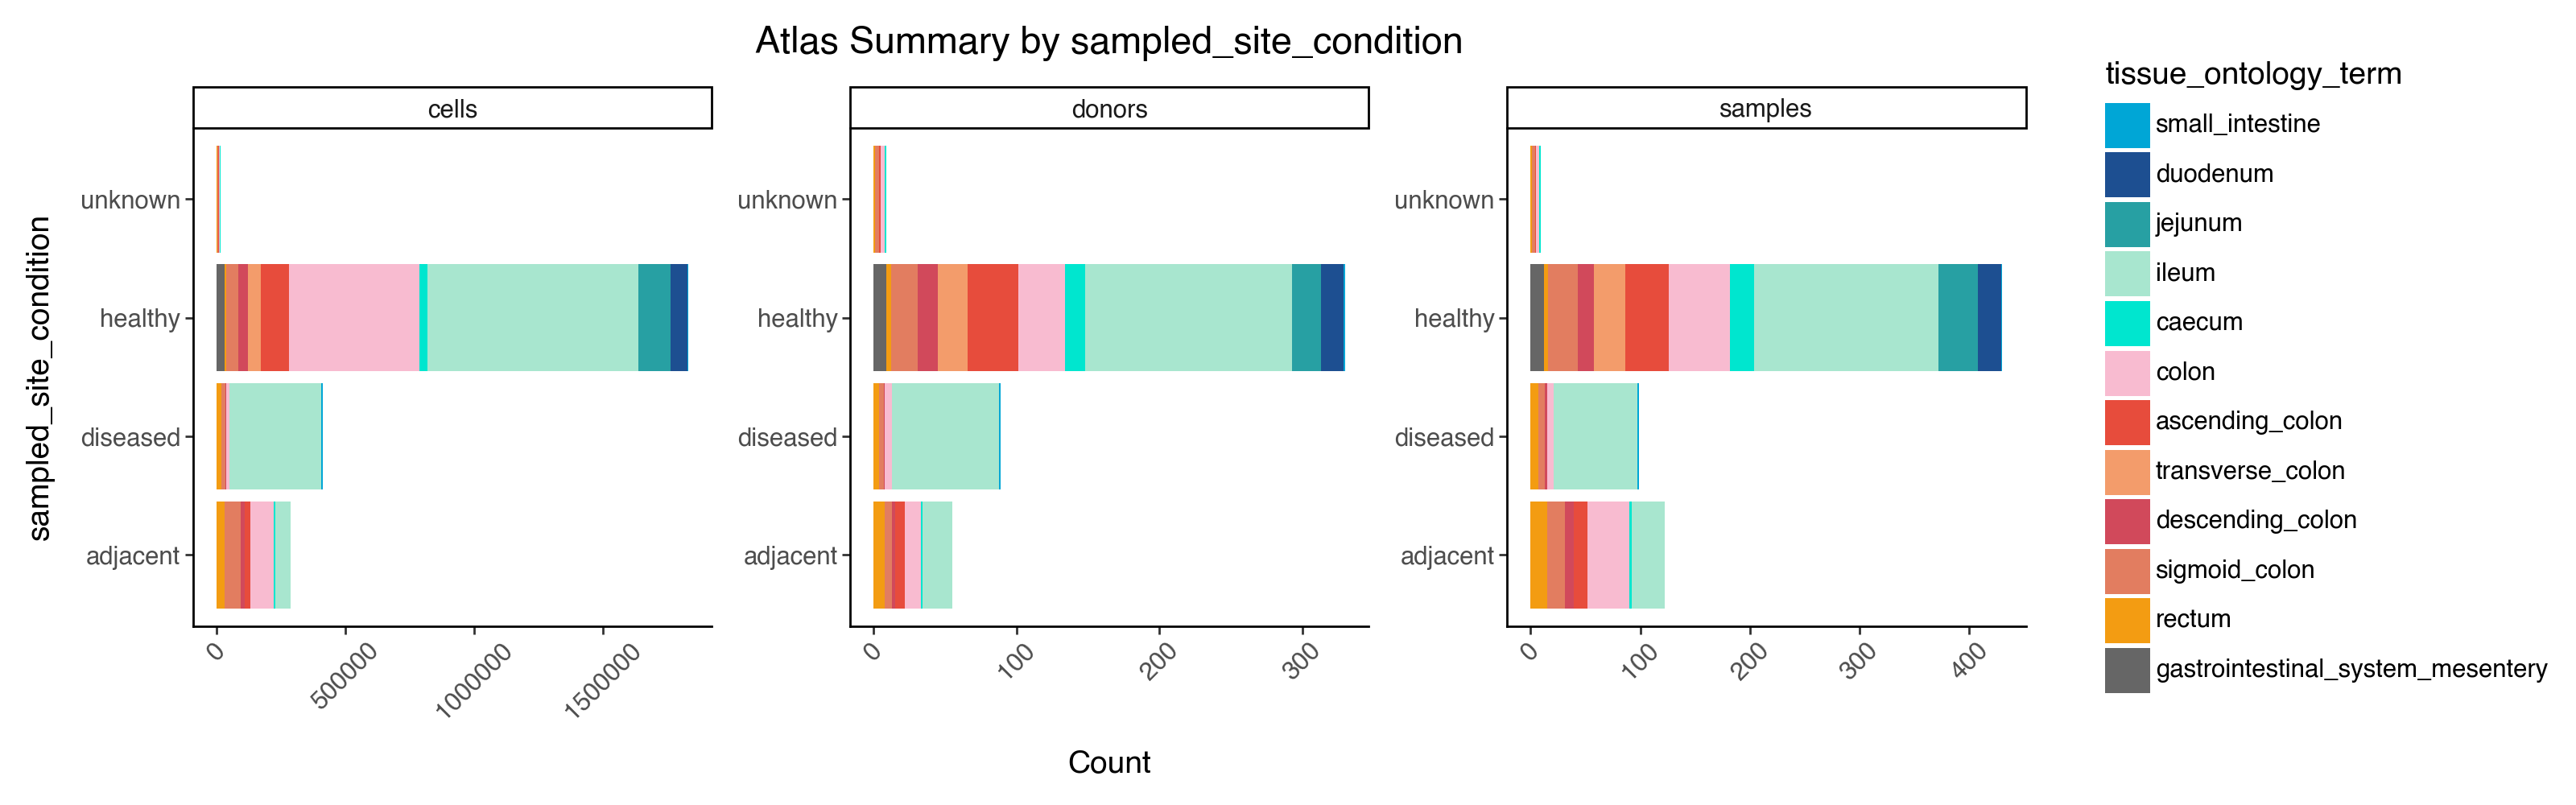

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_sampled_site_condition_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [69]:
group = 'sampled_site_condition'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )
wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/1551545406.py:17: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


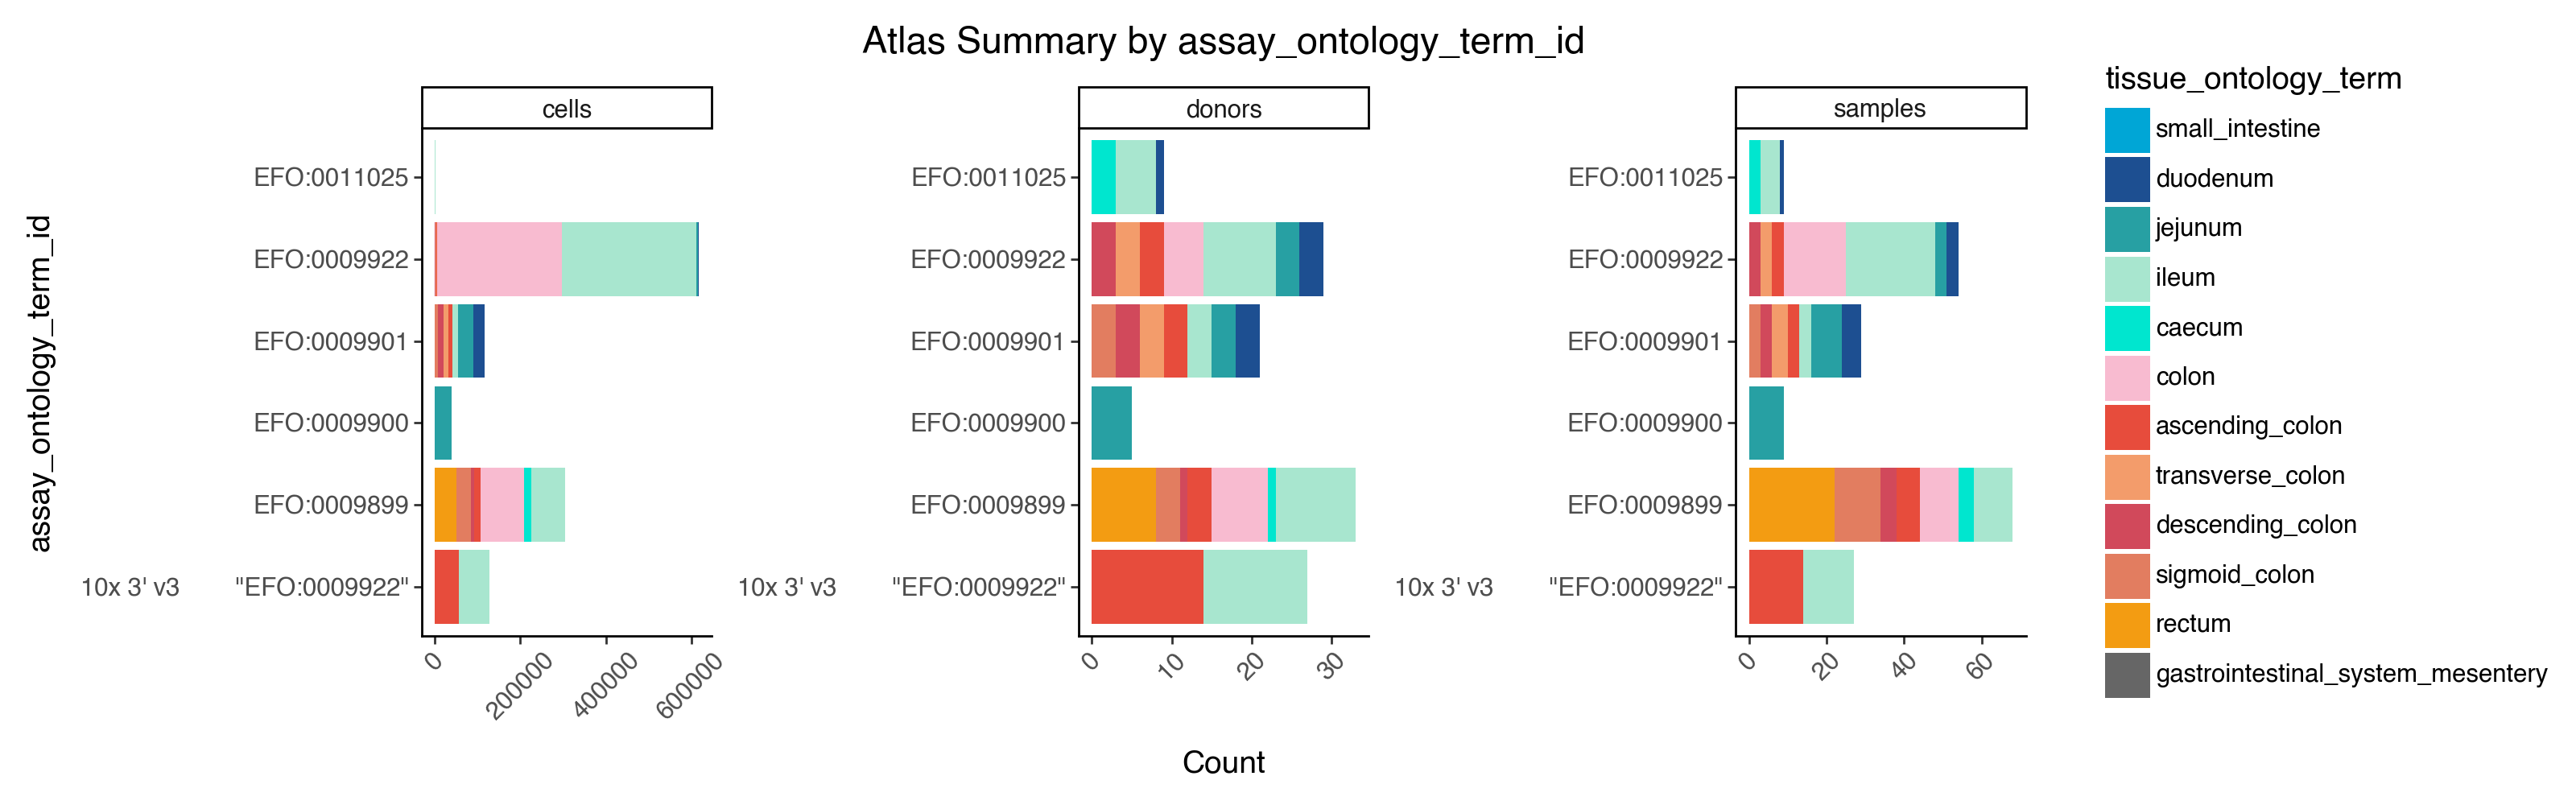

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_assay_ontology_term_id_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [74]:
# tissue_order = list(['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
#                 'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
#                'rectum', 'gastrointestinal_system_mesentery'])

group = 'assay_ontology_term_id'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )
wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/2762301790.py:17: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


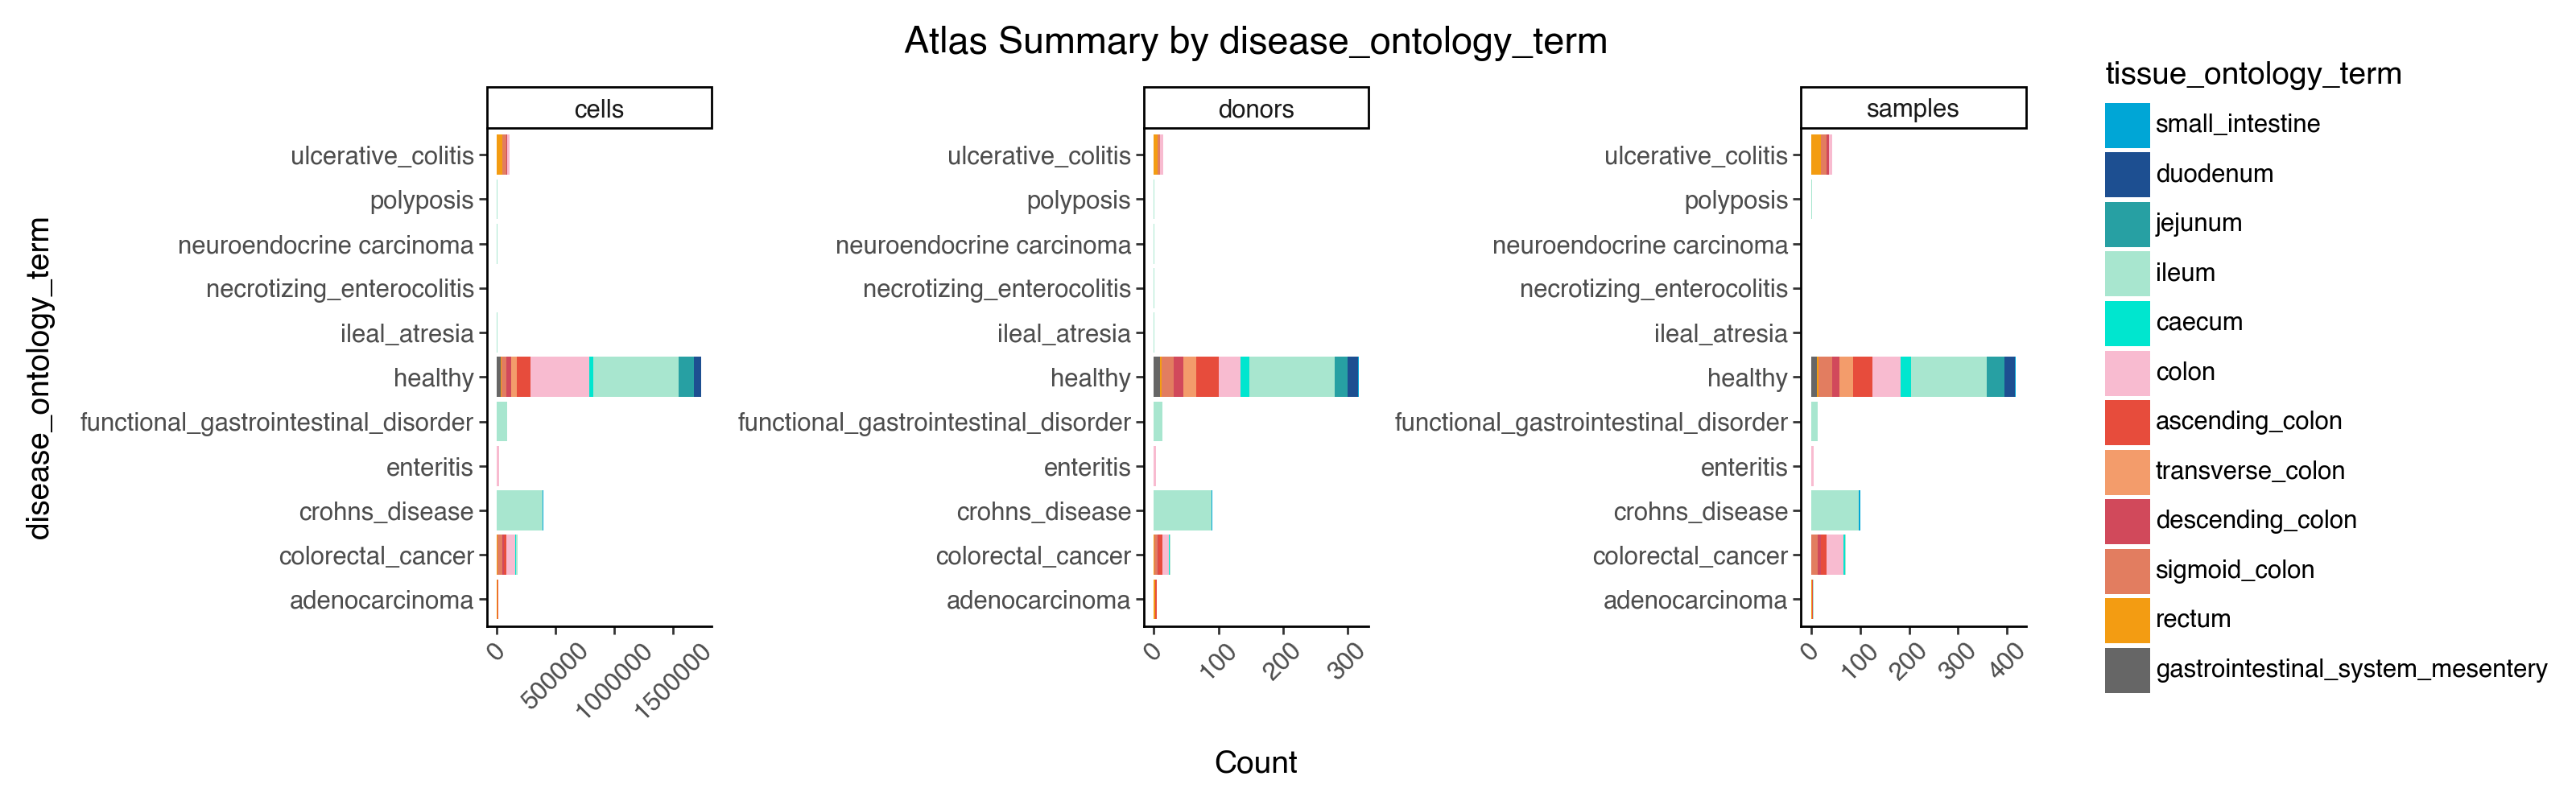

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_disease_ontology_term_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [75]:
# tissue_order = list(['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
#                 'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
#                'rectum', 'gastrointestinal_system_mesentery'])

group = 'disease_ontology_term'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )
wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [20]:
meta

,CellID,dataset_id,donor_id,sample_id,author_cell_type,tissue_ontology_term,tissue_ontology_term_id,tissue_free_text,sample_source,sample_collection_method,...,worksheet,closest_GCA_celltype,Lineage,Differentia,Habitus,Status,Whim,markers,neg_markers,cell_id
0,Dominguez2022_Pan_T7935490_AAACCTGCAAATTGCC,Dominguez2022,A29_390C,Pan_T7935490,Trm_Th1/Th17,ileum,UBERON:0002116,NaN,organ_donor,surgical_resection,...,Dominguez2022,CD4 Th1,Immune,Lymphoid,T Cells,CD4 T Cells,Th1,"CD4, TBX21, IFNG, TNF",NaN,0
1,Dominguez2022_Pan_T7935490_AAACGGGCATCTGGTA,Dominguez2022,A29_390C,Pan_T7935490,Trm_gut_CD8,ileum,UBERON:0002116,NaN,organ_donor,surgical_resection,...,Dominguez2022,CD8 TRM,Immune,Lymphoid,T Cells,CD8 T Cells,TRM (resident memory T cell),"CD8A, CD8B, ITGAE, CD69,ITGA1,RORA",NaN,1
2,Dominguez2022_Pan_T7935490_AAACGGGTCTTGCATT,Dominguez2022,A29_390C,Pan_T7935490,Trm_gut_CD8,ileum,UBERON:0002116,NaN,organ_donor,surgical_resection,...,Dominguez2022,CD8 TRM,Immune,Lymphoid,T Cells,CD8 T Cells,TRM (resident memory T cell),"CD8A, CD8B, ITGAE, CD69,ITGA1,RORA",NaN,2
3,Dominguez2022_Pan_T7935490_AAAGCAATCATCGCTC,Dominguez2022,A29_390C,Pan_T7935490,Trm_gut_CD8,ileum,UBERON:0002116,NaN,organ_donor,surgical_resection,...,Dominguez2022,CD8 TRM,Immune,Lymphoid,T Cells,CD8 T Cells,TRM (resident memory T cell),"CD8A, CD8B, ITGAE, CD69,ITGA1,RORA",NaN,3
4,Dominguez2022_Pan_T7935490_AAAGTAGCAGTCACTA,Dominguez2022,A29_390C,Pan_T7935490,Trm_Tgd,ileum,UBERON:0002116,NaN,organ_donor,surgical_resection,...,Dominguez2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3381934,Drokhylansky2020_H4_S24.TTTGTCAGTCAGTGGA,Drokhylansky2020,H4,H4_S24,Myocyte_1,descending_colon,UBERON:0001158,Submucosa/Mucosa,surgical_donor,surgical_resection,...,Drokhylansky2020,SMC Inner Muscle Cells,Stromal,Smooth Muscle Cells (SMC),Inner Muscle Cells,NaN,NaN,"FOXF2, MORN5",NaN,3381934
3381935,Drokhylansky2020_H4_S24.TTTGTCAGTTACAGAA,Drokhylansky2020,H4,H4_S24,Myocyte_1,descending_colon,UBERON:0001158,Submucosa/Mucosa,surgical_donor,surgical_resection,...,Drokhylansky2020,SMC Inner Muscle Cells,Stromal,Smooth Muscle Cells (SMC),Inner Muscle Cells,NaN,NaN,"FOXF2, MORN5",NaN,3381935
3381936,Drokhylansky2020_H4_S24.TTTGTCAGTTAGAACA,Drokhylansky2020,H4,H4_S24,Glia_3,descending_colon,UBERON:0001158,Submucosa/Mucosa,surgical_donor,surgical_resection,...,Drokhylansky2020,Glia,Stromal,Glia,NaN,NaN,NaN,"NRXN1, S100B, SOX10,CDH19, CRYAB, PLP1, SPP1, ...",NaN,3381936
3381937,Drokhylansky2020_H4_S24.TTTGTCATCCCTCTTT,Drokhylansky2020,H4,H4_S24,Myocyte_2,descending_colon,UBERON:0001158,Submucosa/Mucosa,surgical_donor,surgical_resection,...,Drokhylansky2020,SMC Inner Muscle Cells,Stromal,Smooth Muscle Cells (SMC),Inner Muscle Cells,NaN,NaN,"FOXF2, MORN5",NaN,3381937


In [71]:
def create_faceted_bar_graph(df, grouping_var, color_palette, stacking_var=None, stacking_values=None):
    # Convert stacking variable to categorical with a specific order
    if stacking_var:
        df[stacking_var] = pd.Categorical(df[stacking_var], categories=stacking_values, ordered=True)
        
        # Compute summary statistics per group
        summary_df = df.groupby([grouping_var, stacking_var], observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')  # Assuming 'cell_id' is the index or a column in .obs
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var, stacking_var],
                                    var_name='Category', value_name='Count')

        # Plot with stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill=stacking_var))
            + geom_bar(stat='identity', position='stack')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5),
                axis_text_y=element_text(hjust=1),
                legend_position='right',
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))
            + scale_fill_manual(values=color_palette, limits=stacking_values, breaks=stacking_values)  # Directly use provided color palette
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    else:
        summary_df = df.groupby(grouping_var, observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var],
                                    var_name='Category', value_name='Count')

        # Plot without stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill='Category'))
            + geom_bar(stat='identity', position='dodge')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5), 
                axis_text_y=element_text(hjust=1),  # Justify y-axis labels
                legend_position='right', 
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))  # Adjust figure size for long labels
            + scale_fill_manual(values=color_palette)
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    # Remove y-axis tick labels for the second and third facets
    p = p + theme(
        strip_text_y=element_blank()
    )

    return p


In [72]:

color_palette = pal

grouping_var = 'alignment_software'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

summary_df = df.groupby(grouping_var, observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')
        ).reset_index()

# Melt the DataFrame for easier plotting with facets
melted_df = summary_df.melt(id_vars=[grouping_var],
                            var_name='Category', value_name='Count')

melted_df = melted_df[melted_df.Category.isin(['cells'])].reset_index()

# Plot without stacking
p = (
    ggplot(melted_df, aes(x=grouping_var, y='Count'))
    + geom_bar(stat='identity', position='dodge', fill = pal[0])
    + coord_flip()
    + theme_classic(base_size=14)
    + theme(
        axis_text_x=element_text(rotation=45, hjust=0.5), 
        axis_text_y=element_text(hjust=1),  # Justify y-axis labels
        legend_position='right', 
        subplots_adjust={'right': 0.85},
        figure_size=(16, 8))  # Adjust figure size for long labels
    + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
)

    # Remove y-axis tick labels for the second and third facets
p = p + theme(
    strip_text_y=element_blank()
)

wid = 16
hi = 5
print(p + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


NameError: name 'df' is not defined